# Latency Analysis
Reads the latency CSV log and reproduces the 5-panel time-series plots:
**RTT_ms**, **Processing_ms**, **Network_ms**, **RenderDelay_ms**, **MTP_ms** over elapsed time (seconds).

Outliers (values > mean + 2×std) are highlighted with red dots. A dashed line shows the mean.

In [ ]:
try:
    import pandas, matplotlib, numpy
    print("All packages already available — skipping install.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "numpy", "-q"])
    print("Packages installed. Please restart the kernel, then re-run all cells.")

All packages already available — skipping install.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ── Configuration ──────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/Network_Variant2/WebRTC/Ctcp_Stcp/Exp1/latency_log_webrtc_20260523_224156.csv"   # adjust path if needed
OUTLIER_THRESHOLD = 2          # multiples of std above mean = outlier
FIG_WIDTH  = 12
FIG_HEIGHT = 5
DPI        = 400

In [ ]:
# ── Load data ──────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(3)

Loaded 1807 rows  |  columns: ['seq', 'cmd_seq_echo', 'T0_ms', 'T1_ms', 'T3_ms', 'TQ_ms', 'T4_ms', 'T6_ms', 'T7_ms', 'RTT_ms', 'Processing_ms', 'QueueDelay_ms', 'Network_ms', 'RenderDelay_ms', 'MTP_ms', 'Jitter_ms']


,seq,cmd_seq_echo,T0_ms,T1_ms,T3_ms,TQ_ms,T4_ms,T6_ms,T7_ms,RTT_ms,Processing_ms,QueueDelay_ms,Network_ms,RenderDelay_ms,MTP_ms,Jitter_ms
0,89,1,1779576130406,1779576130407,1779576130413,1779576130415,1779576130415,1779576130445,1779576130478,38,0,2,36,33,71,25.3230
1,90,3,1779576130445,1779576130445,1779576130450,1779576130456,1779576130456,1779576130478,1779576130512,33,0,6,27,34,67,24.2651
2,91,5,1779576130511,1779576130511,1779576130516,1779576130517,1779576130517,1779576130543,1779576130576,32,0,1,31,33,65,23.1264


In [ ]:
# ── Pre-process ────────────────────────────────────────────────────
# Drop the first row if it is the warm-up / outlier spike
# (RTT > 1 000 ms means it is the very first connection packet)
df_clean = df[df["RTT_ms"] < 1_000].copy().reset_index(drop=True)

# Elapsed time in seconds (relative to first clean packet)
t0 = df_clean["T0_ms"].iloc[0]
df_clean["elapsed_s"] = (df_clean["T0_ms"] - t0) / 1_000.0

# Convert Processing from ns → ms
# df_clean["Processing_ms"] = df_clean["Processing_ns"] / 1_000_000.0

print(f"Clean rows: {len(df_clean)}")
print(f"Duration  : {df_clean['elapsed_s'].max():.1f} s")

Clean rows: 1805
Duration  : 103.5 s


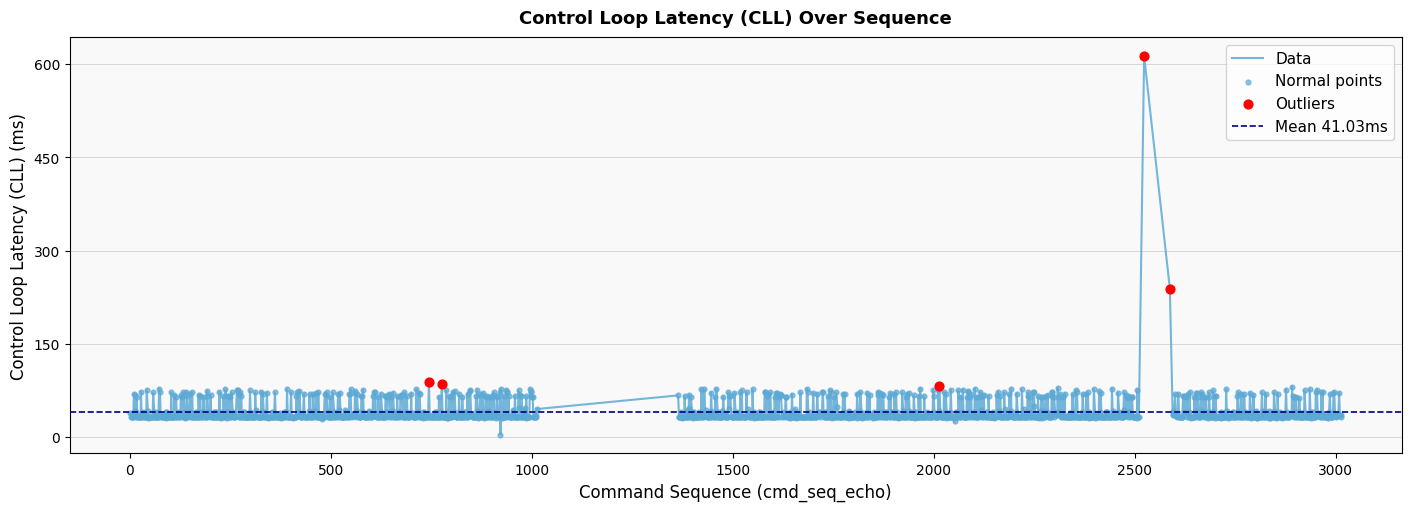

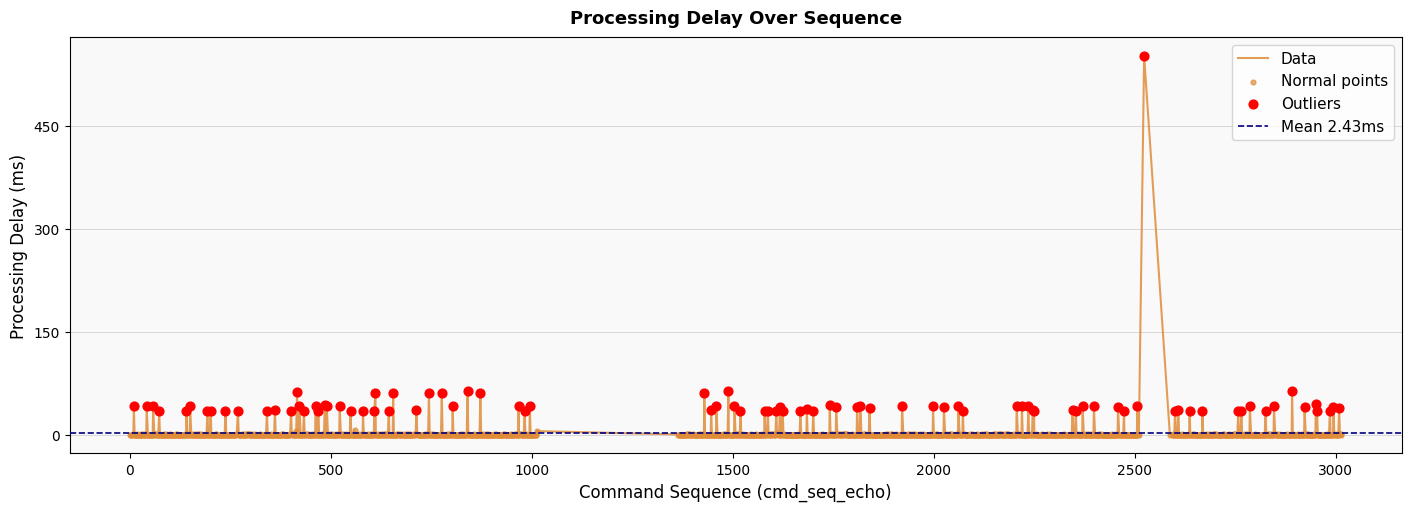

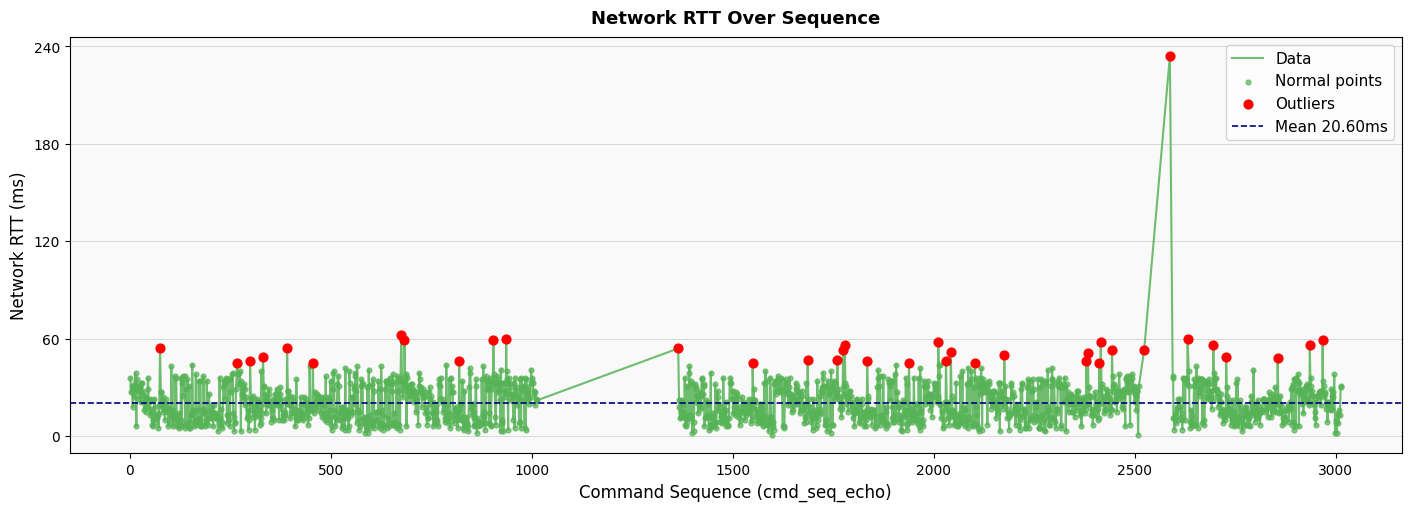

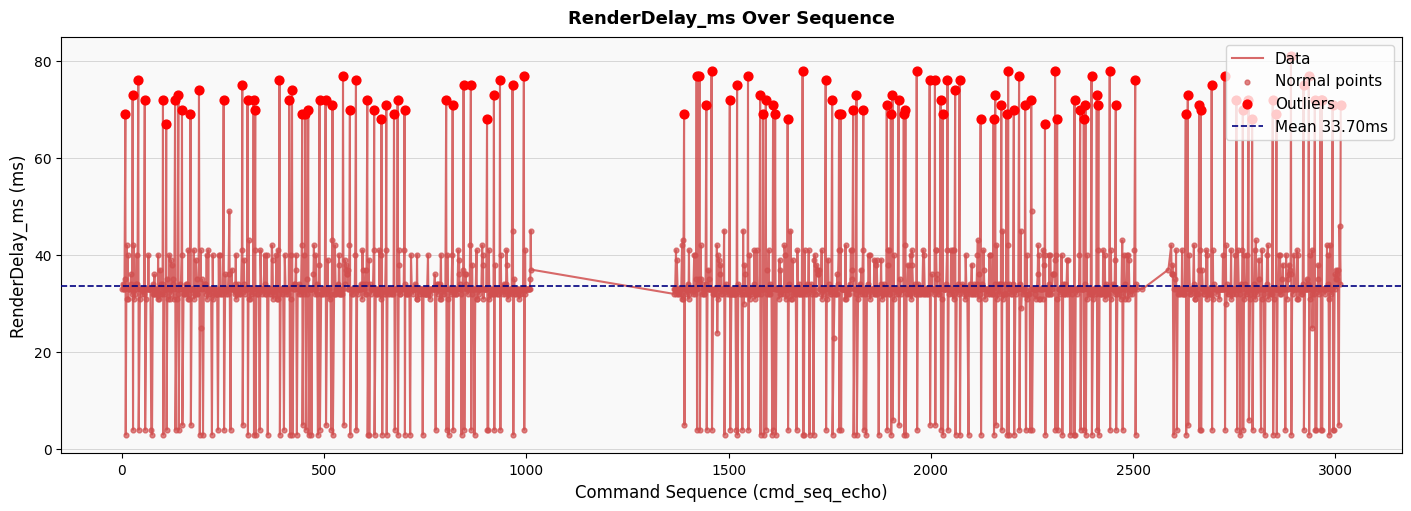

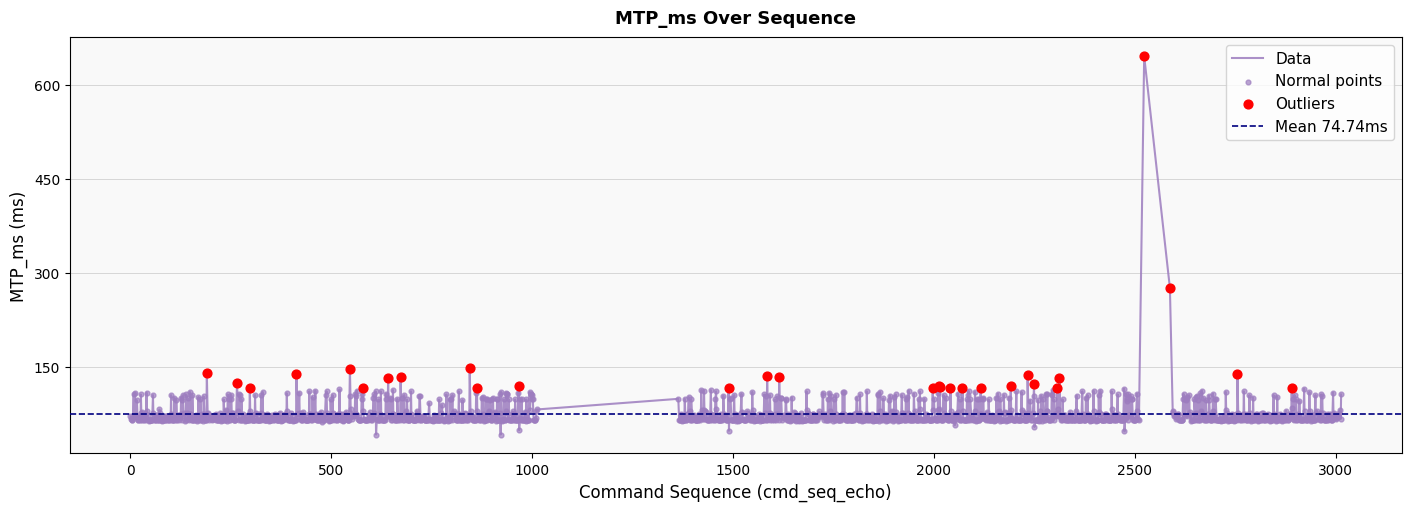

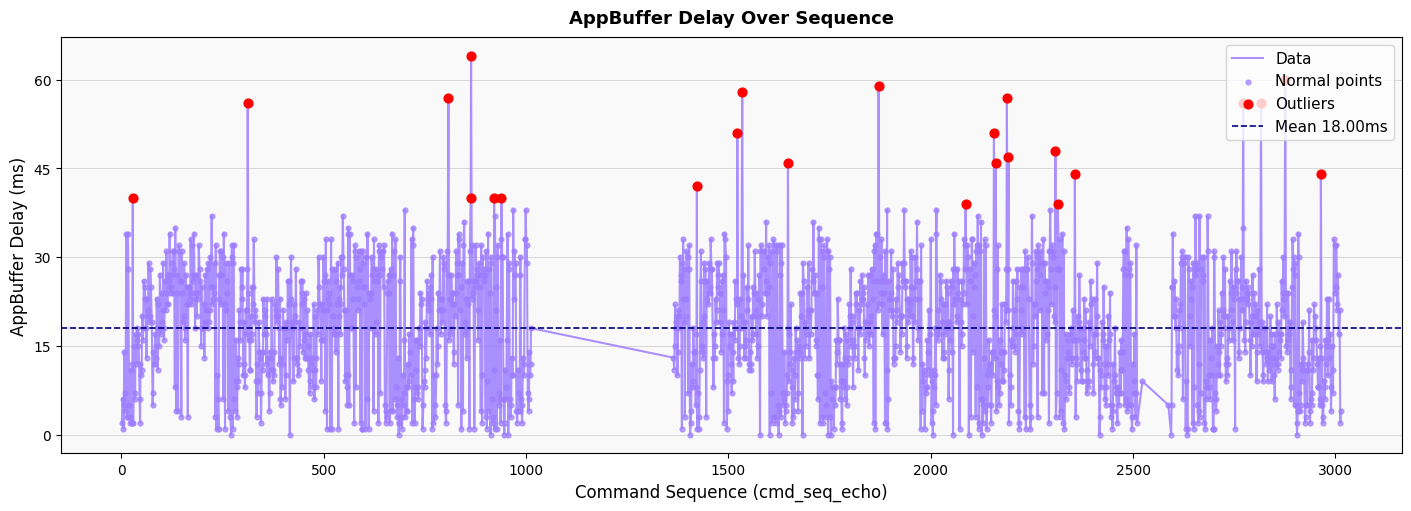

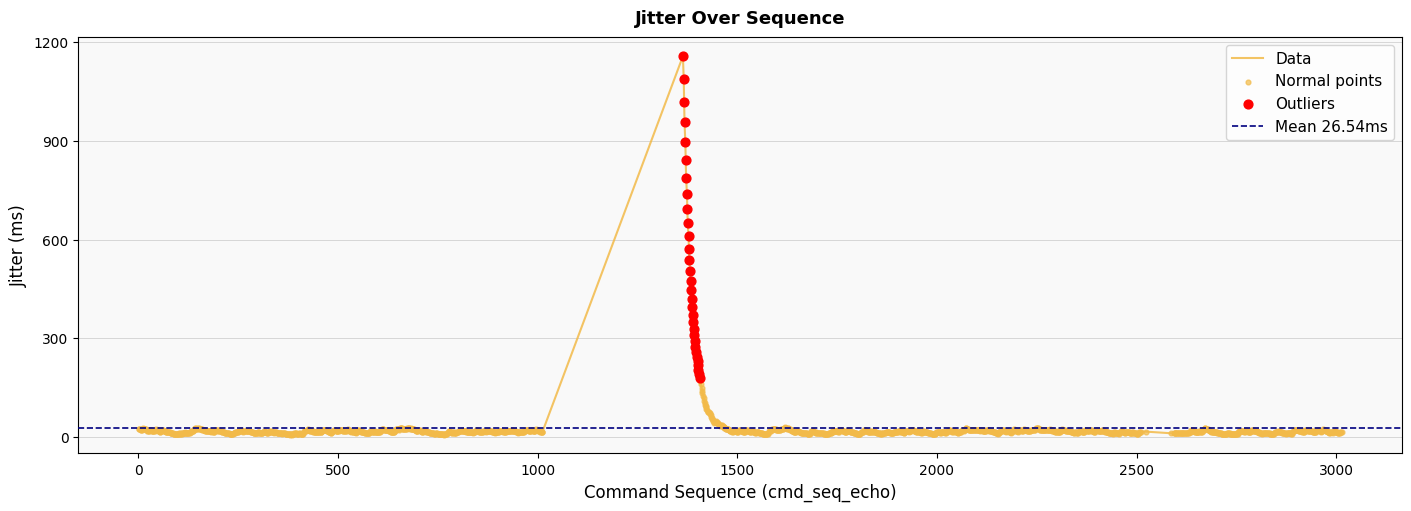

In [ ]:
panels = [
    dict(col="RTT_ms",         label="Control Loop Latency (CLL) (ms)", color="#5da9d5", title="Control Loop Latency (CLL) Over Sequence"),
    dict(col="Processing_ms",  label="Processing Delay (ms)",           color="#e08c39", title="Processing Delay Over Sequence"),
    dict(col="Network_ms",     label="Network RTT (ms)",                color="#56b356", title="Network RTT Over Sequence"),
    dict(col="RenderDelay_ms", label="RenderDelay_ms (ms)",              color="#d14f4f", title="RenderDelay_ms Over Sequence"),
    dict(col="MTP_ms",         label="MTP_ms (ms)",                     color="#9d7dbf", title="MTP_ms Over Sequence"),
    dict(col="QueueDelay_ms",  label="AppBuffer Delay (ms)",             color="#9d7dff", title="AppBuffer Delay Over Sequence"),
    dict(col="Jitter_ms",      label="Jitter (ms)",                     color="#f2ba49", title="Jitter Over Sequence")
]

# Use command sequence for x-axis
x = df_clean["cmd_seq_echo"].values

# Create separate figure for each metric
for p in panels:
    # Skip plotting if the column doesn't exist in df_clean (e.g., if Jitter_ms wasn't calculated earlier)
    if p["col"] not in df_clean.columns:
        print(f"Skipping plot for {p['col']} as it is not in the DataFrame.")
        continue

    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    y      = df_clean[p["col"]].values
    mean   = y.mean()
    std    = y.std()
    is_out = y > mean + OUTLIER_THRESHOLD * std

    # Main line
    ax.plot(x, y, color=p["color"], linewidth=1.5, alpha=0.85, zorder=2, label="Data")

    # Normal scatter points
    ax.scatter(x[~is_out], y[~is_out],
               color=p["color"], s=12, zorder=3, alpha=0.7, label="Normal points")

    # Outlier points in red
    if is_out.any():
        ax.scatter(x[is_out], y[is_out],
                   color="red", s=40, zorder=5, label="Outliers")

    # Mean dashed line
    ax.axhline(mean, color="navy", linewidth=1.2, linestyle="--", zorder=4, label=f"Mean {mean:.2f}ms")

    # Legend
    ax.legend(loc="upper right", fontsize=11, framealpha=0.8)

    ax.set_title(p["title"], fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Command Sequence (cmd_seq_echo)", fontsize=12)
    ax.set_ylabel(p["label"], fontsize=12)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", color="gray", linewidth=0.4, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

    plt.show()

In [ ]:
# ── Summary statistics ────────────────────────────────────────────
# Renaming columns for display if they exist in df_clean
stat_mapping = {
    "RTT_ms": "Control Loop Latency (CLL) (ms)",
    "Processing_ns": "Processing Delay (ns)",
    "Network_ms": "Network RTT (ms)",
    "RenderDelay_ms": "Render Delay (ms)",
    "MTP_ms": "MTP (ms)",
    "QueueDelay_ms": "AppBuffer Delay (ms)"
}

# Filter to columns that actually exist
stat_cols = [c for c in ["RTT_ms", "Processing_ns", "Network_ms", "RenderDelay_ms", "MTP_ms", "QueueDelay_ms"] if c in df_clean.columns]
summary_df = df_clean[stat_cols].describe().round(3)
summary_df.columns = [stat_mapping.get(col, col) for col in summary_df.columns]
display(summary_df)

,Control Loop Latency (CLL) (ms),Processing Delay (ns),Network RTT (ms),Render Delay (ms),MTP (ms),AppBuffer Delay (ms)
count,2104.000,2104.000,2104.000,2104.000,2104.000,2104.000
mean,18.454,0.062,0.863,17.994,36.448,17.531
std,10.531,0.332,0.641,10.470,9.707,10.540
min,1.000,0.000,0.000,0.000,3.000,0.000
25%,10.000,0.000,0.000,9.000,32.000,9.000
50%,18.000,0.000,1.000,18.000,33.000,17.000
75%,27.000,0.000,1.000,26.000,38.000,26.000
max,51.000,6.000,4.000,51.000,83.000,51.000


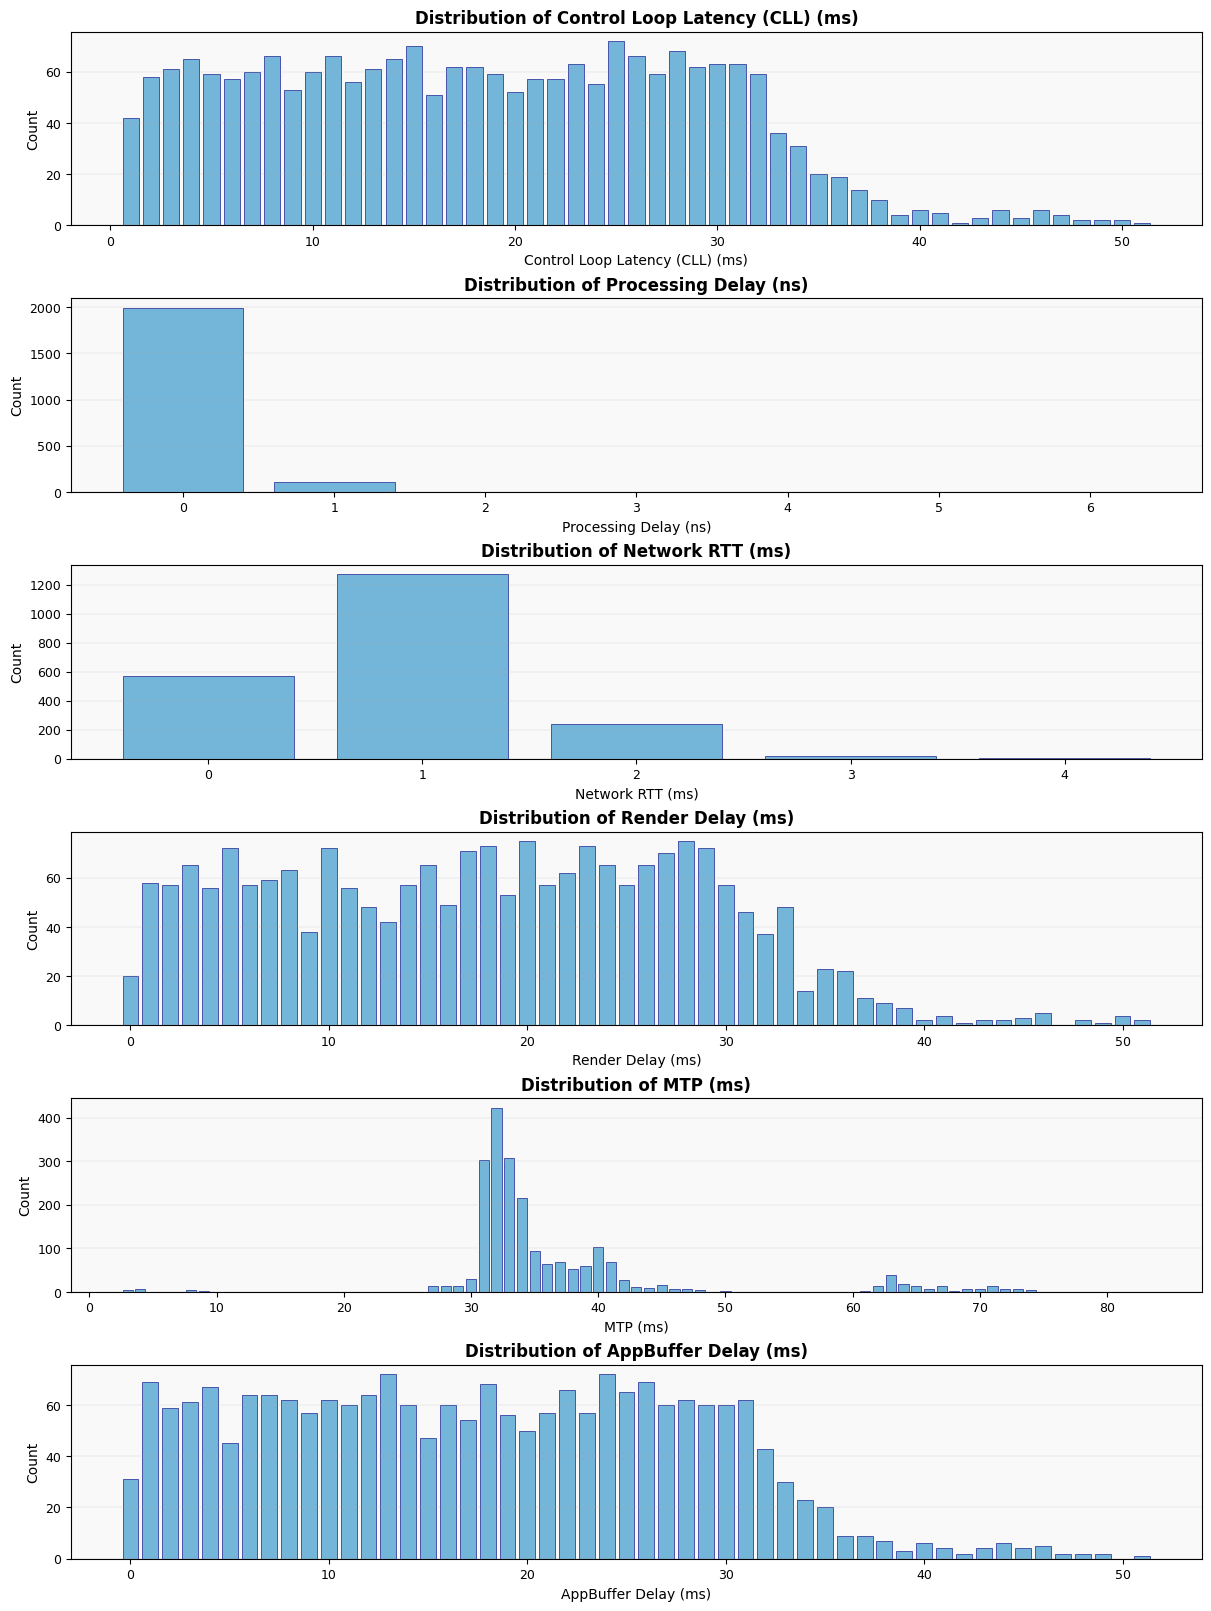


Control Loop Latency (CLL) (ms) value counts (top 15):


,count
RTT_ms,
1,42
2,58
3,61
4,65
5,59
6,57
7,60
8,66
9,53



Processing Delay (ns) value counts (top 15):


,count
Processing_ns,
0,1995
1,104
5,4
6,1



Network RTT (ms) value counts (top 15):


...

,count
RenderDelay_ms,
0,20
1,58
2,57
3,65
4,56
5,72
6,57
7,59
8,63



MTP (ms) value counts (top 15):


,count
MTP_ms,
3,4
4,7
7,1
8,4
9,2
13,1
23,1
26,1
27,13



AppBuffer Delay (ms) value counts (top 15):


,count
QueueDelay_ms,
0,31
1,69
2,59
3,61
4,67
5,45
6,64
7,64
8,62


In [ ]:
# Distribution histogram (count of each value) for all latency metrics
fig, axes = plt.subplots(len(stat_cols), 1, figsize=(12, 16), constrained_layout=True)

value_counts_by_metric = {}

for ax, col in zip(axes, stat_cols):
    s = df_clean[col].copy()
    display_name = stat_mapping.get(col, col)

    # Processing_ms is continuous; round slightly so the distribution is readable
    if col == "Processing_ms":
        s = s.round(3)

    counts = s.value_counts().sort_index()
    value_counts_by_metric[col] = counts

    ax.bar(counts.index, counts.values, color="#5da9d5", alpha=0.85, width=0.8, edgecolor="navy", linewidth=0.5)
    ax.set_title(f"Distribution of {display_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel(display_name, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(axis="y", linewidth=0.3, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

plt.show()

# Optional: frequency tables (value -> count) for each metric
for col in stat_cols:
    display_name = stat_mapping.get(col, col)
    print(f"\n{display_name} value counts (top 15):")
    display(value_counts_by_metric[col].head(15))

/tmp/ipykernel_2803/1377685427.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


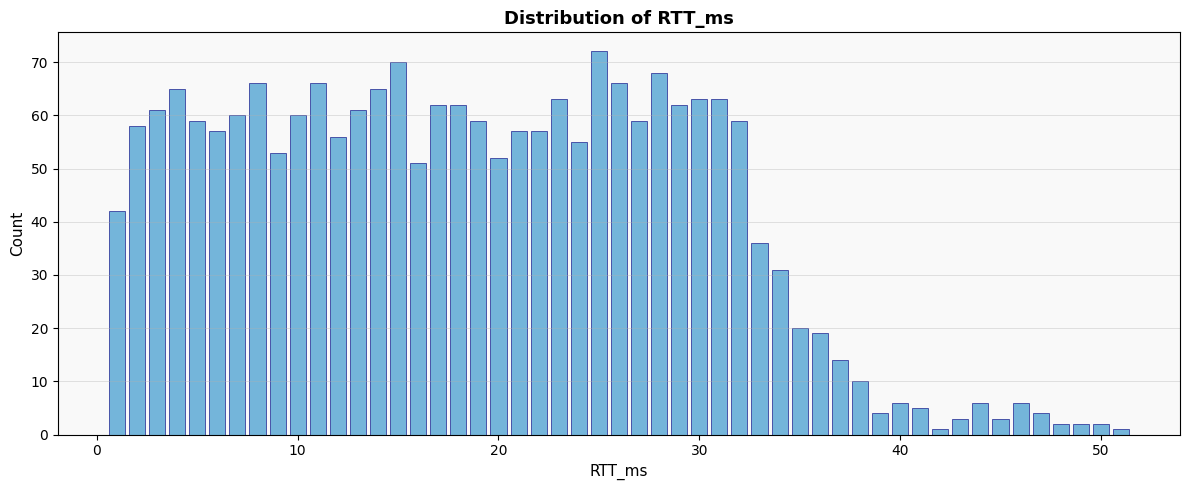

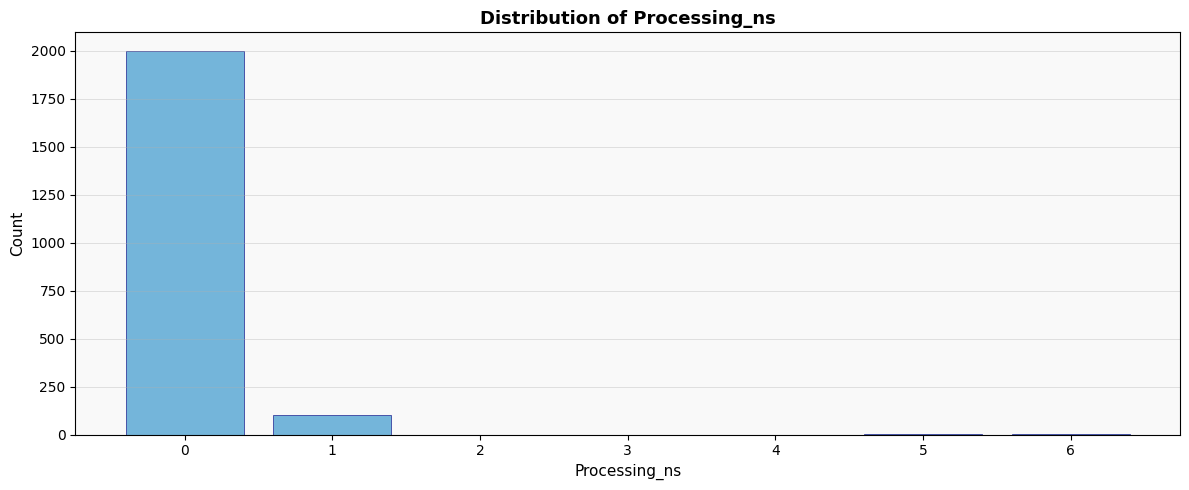

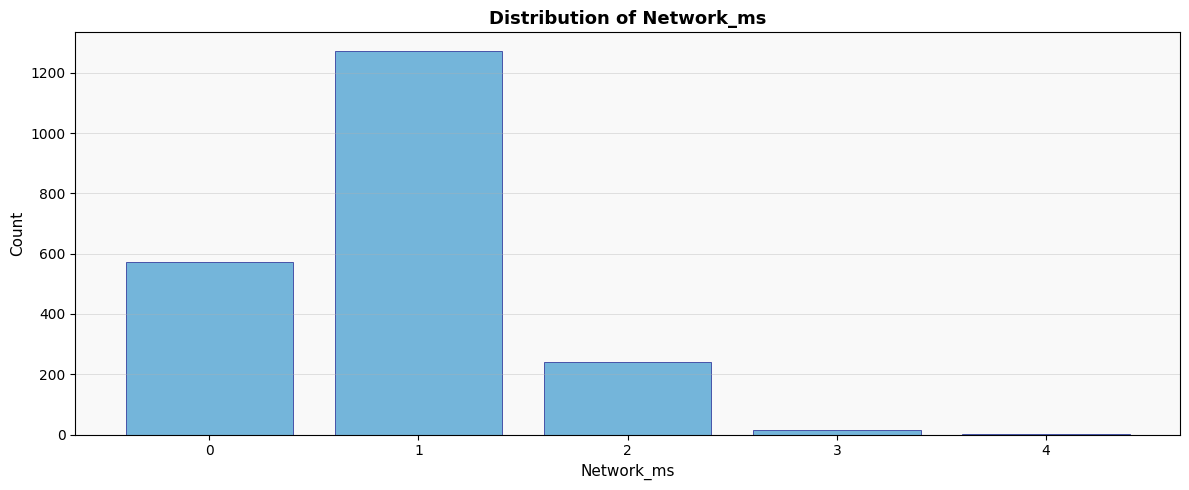

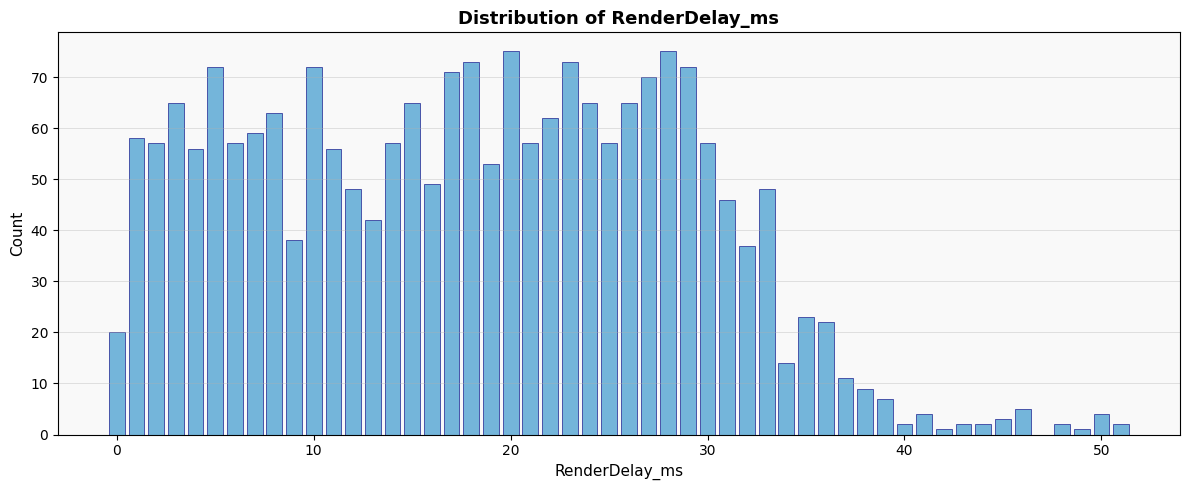

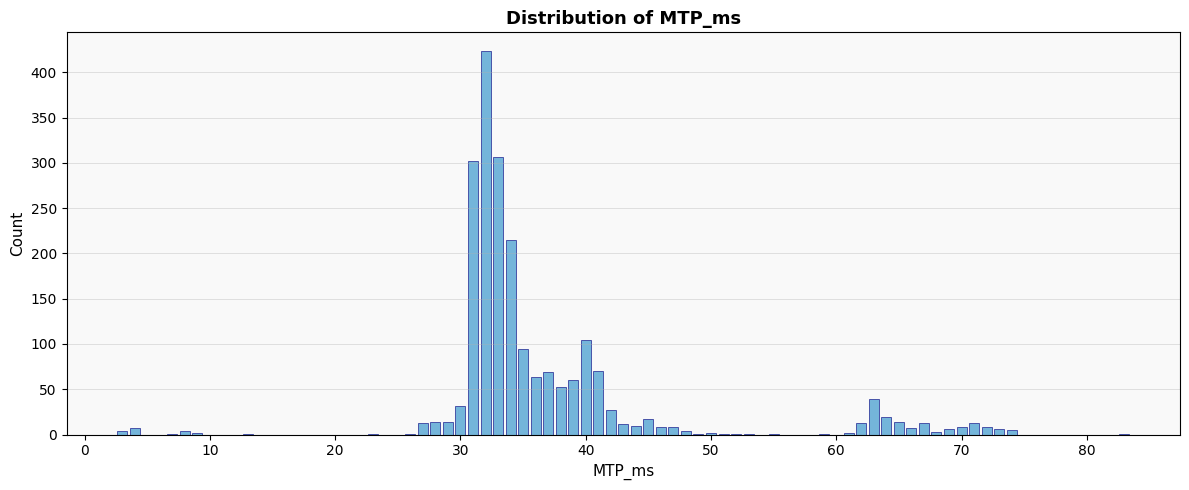

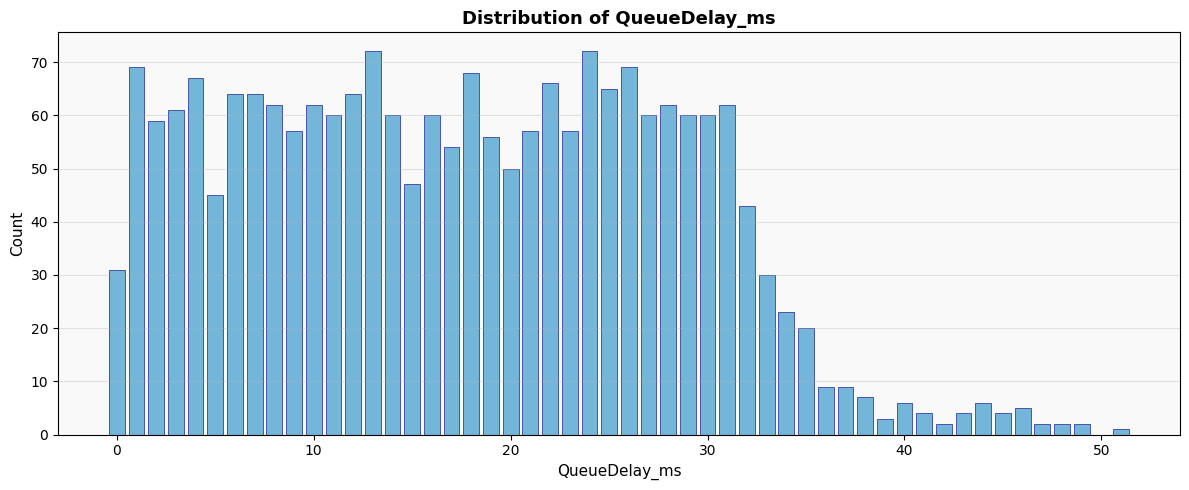

In [ ]:
# ── Individual Distribution Plots (One per cell output) ──────────
for col in stat_cols:
    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

    s = df_clean[col].copy()

    # Processing_ms is continuous; round slightly so the distribution is readable
    if col == "Processing_ms":
        s = s.round(3)

    counts = s.value_counts().sort_index()

    ax.bar(counts.index, counts.values, color="#5da9d5", alpha=0.85, width=0.8, edgecolor="navy", linewidth=0.5)
    ax.set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

    plt.tight_layout()
    plt.show()

In [ ]:
# Percentage of missing cmd_seq from the CSV (based on sequence gaps)
if "cmd_seq_echo" not in df.columns:
    print("Column 'cmd_seq_echo' not found in CSV.")
else:
    cmd = pd.to_numeric(df["cmd_seq_echo"], errors="coerce").dropna().astype(int)

    if cmd.empty:
        print("No valid cmd_seq_echo values found.")
    else:
        observed = set(cmd.unique())
        expected = set(range(cmd.min(), cmd.max() + 1))
        missing = expected - observed

        missing_count = len(missing)
        expected_count = len(expected)
        missing_pct = (missing_count / expected_count) * 100 if expected_count else 0.0

        print(f"cmd_seq range      : {cmd.min()} to {cmd.max()}")
        print(f"Expected seq count : {expected_count}")
        print(f"Observed seq count : {len(observed)}")
        print(f"Missing seq count  : {missing_count}")
        print(f"Missing percentage : {missing_pct:.2f}%")

        # Optional: show first few missing sequence numbers
        if missing_count:
            print("First missing cmd_seq values:", sorted(missing)[:20])

# Optional: percentage of null/blank cmd_seq cells in CSV
null_pct = df["cmd_seq"].isna().mean() * 100 if "cmd_seq" in df.columns else np.nan
print(f"Null cmd_seq cell percentage: {null_pct:.2f}%")

cmd_seq range      : 2 to 3012
Expected seq count : 3011
Observed seq count : 2104
Missing seq count  : 907
Missing percentage : 30.12%
First missing cmd_seq values: [5, 9, 13, 14, 16, 20, 26, 29, 30, 31, 32, 34, 38, 42, 44, 45, 55, 59, 60, 67]
Null cmd_seq cell percentage: nan%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ── Configuration ──────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/BaseLine/Cudp_Sudp/Exp1/unity_packet_log_20260523_163720.csv"   # adjust path if needed
# ── Load data ──────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(3)

Loaded 2447 rows  |  columns: ['utc_iso', 'unix_ms', 'seq', 'cmd_seq_echo', 't0_echo', 't1_echo', 't3_recv', 'tq_dequeue', 't4_physics', 't5_send', 't6_unity']


,utc_iso,unix_ms,seq,cmd_seq_echo,t0_echo,t1_echo,t3_recv,tq_dequeue,t4_physics,t5_send,t6_unity
0,2026-05-23T16:37:56.4968610Z,1779554276496,1,0,0,0,1779554276461,1779554276468,1779554276468,1779554276468,1779554276466
1,2026-05-23T16:37:56.5305780Z,1779554276530,2,0,0,0,1779554276461,1779554276468,1779554276521,1779554276521,1779554276518
2,2026-05-23T16:37:56.5653830Z,1779554276565,3,0,0,0,1779554276461,1779554276468,1779554276559,1779554276559,1779554276556


In [ ]:
# Percentage of missing cmd_seq from the CSV (based on sequence gaps)
if "cmd_seq" not in df.columns:
    print("Column 'cmd_seq' not found in CSV.")
else:
    cmd = pd.to_numeric(df["cmd_seq"], errors="coerce").dropna().astype(int)

    if cmd.empty:
        print("No valid cmd_seq values found.")
    else:
        observed = set(cmd.unique())
        expected = set(range(cmd.min(), cmd.max() + 1))
        missing = expected - observed

        missing_count = len(missing)
        expected_count = len(expected)
        missing_pct = (missing_count / expected_count) * 100 if expected_count else 0.0

        print(f"cmd_seq range      : {cmd.min()} to {cmd.max()}")
        print(f"Expected seq count : {expected_count}")
        print(f"Observed seq count : {len(observed)}")
        print(f"Missing seq count  : {missing_count}")
        print(f"Missing percentage : {missing_pct:.2f}%")

        # Optional: show first few missing sequence numbers
        if missing_count:
            print("First missing cmd_seq values:", sorted(missing)[:20])

# Optional: percentage of null/blank cmd_seq cells in CSV
null_pct = df["cmd_seq"].isna().mean() * 100 if "cmd_seq" in df.columns else np.nan
print(f"Null cmd_seq cell percentage: {null_pct:.2f}%")

Column 'cmd_seq' not found in CSV.
Null cmd_seq cell percentage: nan%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ── Configuration ──────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/BaseLine/Cudp_Sudp/Exp1/unity_packet_log_20260523_163720.csv"   # adjust path if needed
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(3)

Loaded 2447 rows  |  columns: ['utc_iso', 'unix_ms', 'seq', 'cmd_seq_echo', 't0_echo', 't1_echo', 't3_recv', 'tq_dequeue', 't4_physics', 't5_send', 't6_unity']


,utc_iso,unix_ms,seq,cmd_seq_echo,t0_echo,t1_echo,t3_recv,tq_dequeue,t4_physics,t5_send,t6_unity
0,2026-05-23T16:37:56.4968610Z,1779554276496,1,0,0,0,1779554276461,1779554276468,1779554276468,1779554276468,1779554276466
1,2026-05-23T16:37:56.5305780Z,1779554276530,2,0,0,0,1779554276461,1779554276468,1779554276521,1779554276521,1779554276518
2,2026-05-23T16:37:56.5653830Z,1779554276565,3,0,0,0,1779554276461,1779554276468,1779554276559,1779554276559,1779554276556


In [ ]:
# Percentage of missing cmd_seq from the CSV (based on sequence gaps)
print("Without Emulation")
if "seq" not in df.columns:
    print("Column 'cmd_seq' not found in CSV.")
else:
    cmd = pd.to_numeric(df["seq"], errors="coerce").dropna().astype(int)

    if cmd.empty:
        print("No valid cmd_seq values found.")
    else:
        observed = set(cmd.unique())
        expected = set(range(cmd.min(), cmd.max() + 1))
        missing = expected - observed

        missing_count = len(missing)
        expected_count = len(expected)
        missing_pct = (missing_count / expected_count) * 100 if expected_count else 0.0

        print(f"cmd_seq range      : {cmd.min()} to {cmd.max()}")
        print(f"Expected seq count : {expected_count}")
…print(f"Null cmd_seq cell percentage: {null_pct:.2f}%")

Without Emulation
cmd_seq range      : 1 to 2447
Expected seq count : 2447
Observed seq count : 2447
Missing seq count  : 0
Missing percentage : 0.00%
Null cmd_seq cell percentage: nan%


In [ ]:
stat_cols = ["RTT_ms", "Processing_ns", "Network_ms", "RenderDelay_ms", "MTP_ms"]

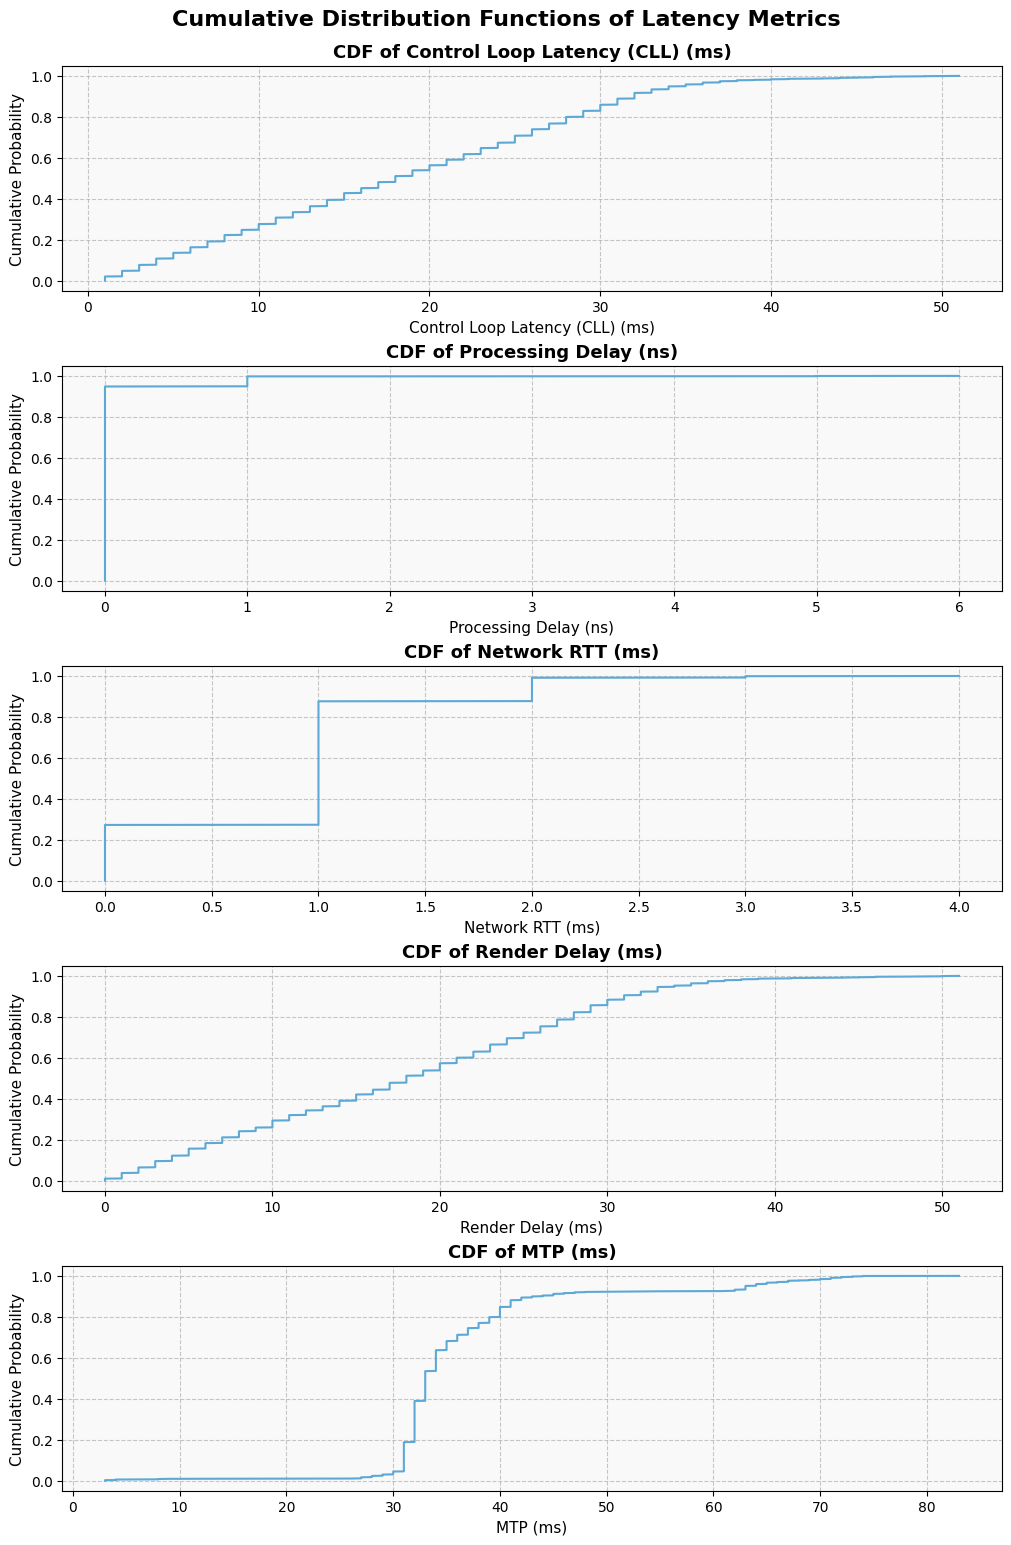

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(stat_cols), 1, figsize=(10, 15), constrained_layout=True)

for i, col in enumerate(stat_cols):
    ax = axes[i]
    display_name = stat_mapping.get(col, col)

    # Get data and drop NaNs
    data = df_clean[col].dropna()

    # Sort the data
    sorted_data = np.sort(data)

    # Calculate CDF
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

    # Plot CDF
    ax.plot(sorted_data, cdf, color='#5da9d5', linewidth=1.5)

    ax.set_title(f"CDF of {display_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(display_name, fontsize=11)
    ax.set_ylabel("Cumulative Probability", fontsize=11)
    ax.grid(axis="both", linestyle='--', alpha=0.7)
    ax.set_facecolor("#f9f9f9")
    ax.tick_params(axis="both", labelsize=10)

plt.suptitle("Cumulative Distribution Functions of Latency Metrics", fontsize=16, fontweight="bold", y=1.02)
plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# #Network_ms
# def load_and_preprocess_latency_data(csv_path):
#     """Loads a latency CSV, cleans it, and pre-processes columns."""
#     df = pd.read_csv(csv_path)

#     # Drop the first row if it is the warm-up / outlier spike
#     # (RTT > 1 000 ms means it is the very first connection packet)
#     df_clean = df[df["RTT_ms"] < 1_000].copy().reset_index(drop=True)

#     # Elapsed time in seconds (relative to first clean packet)
#     t0 = df_clean["T0_ms"].iloc[0]
#     df_clean["elapsed_s"] = (df_clean["T0_ms"] - t0) / 1_000.0

#     # Convert Processing from ns → ms
#     df_clean["Processing_ms"] = df_clean["Processing_ns"] / 1_000_000.0
#     return df_clean

# # --- User Input Required ---
# # Please specify the metric you want to plot
# # (e.g., "RTT_ms", "Processing_ms", "Network_ms", "RenderDelay_ms", "MTP_ms")
# metric_to_plot = "RTT_ms"

# # Please provide the paths to the three CSV files you want to compare.
# # These files should contain the specified metric (e.g., latency log files).
# # Update these paths with your actual file locations.
# csv_paths_for_comparison = [
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/same machine/exp1/latency_log_20260402_140319.csv",
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/different Machine/exp3_Apr7_00:05 /latency_log_20260406_182121.csv", # Placeholder: replace with your second file path
#     "/content/drive/MyDrive/Teleoperation experiments/udp/Without emulation/latency_log_20260320_061137.csv"  # Placeholder: replace with your third file path
# ]

# # Validate that three paths are provided
# if len(csv_paths_for_comparison) != 3:
#     raise ValueError("Please provide exactly three CSV file paths for comparison in 'csv_paths_for_comparison'.")

# plt.figure(figsize=(10, 6))

# for i, path in enumerate(csv_paths_for_comparison):
#     print(f"Processing file: {os.path.basename(path)}")
#     try:
#         df_current = load_and_preprocess_latency_data(path)

#         if metric_to_plot not in df_current.columns:
#             print(f"Warning: Metric '{metric_to_plot}' not found in {os.path.basename(path)}. Skipping this file.")
#             continue

#         data = df_current[metric_to_plot].dropna()
#         sorted_data = np.sort(data)
#         cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

#         label = f"File {i+1}: {os.path.basename(path)}" # Use a more distinct label
#         plt.plot(sorted_data, cdf, label=label, linewidth=1.5)
#     except FileNotFoundError:
#         print(f"Error: File not found at {path}. Please check the path.")
#     except Exception as e:
#         print(f"An error occurred processing {os.path.basename(path)}: {e}")

# plt.title(f"Cumulative Distribution Function of {metric_to_plot}", fontsize=16, fontweight="bold")
# plt.xlabel(metric_to_plot, fontsize=12)
# plt.ylabel("Cumulative Probability", fontsize=12)
# plt.grid(axis="both", linestyle='--', alpha=0.7)
# plt.legend(loc="lower right", fontsize=10)
# plt.gca().set_facecolor("#f9f9f9")
# plt.tick_params(axis="both", labelsize=10)
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os

# def load_and_preprocess_latency_data(csv_path):
#     """Loads a latency CSV, cleans it, and pre-processes columns."""
#     df = pd.read_csv(csv_path)

#     # Drop the first row if it is the warm-up / outlier spike
#     # (RTT > 1 000 ms means it is the very first connection packet)
#     df_clean = df[df["RTT_ms"] < 1_000].copy().reset_index(drop=True)

#     # Elapsed time in seconds (relative to first clean packet)
#     t0 = df_clean["T0_ms"].iloc[0]
#     df_clean["elapsed_s"] = (df_clean["T0_ms"] - t0) / 1_000.0

#     # Convert Processing from ns → ms
#     df_clean["Processing_ms"] = df_clean["Processing_ns"] / 1_000_000.0
#     return df_clean

# # --- User Input Required ---
# # Please specify the metric you want to plot
# # (e.g., "RTT_ms", "Processing_ms", "Network_ms", "RenderDelay_ms", "MTP_ms")
# metric_to_plot = "MTP_ms"

# # Define the paths and their desired labels
# file_labels = {
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/same machine/exp1/latency_log_20260402_140319.csv": "same machine",
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/different Machine/exp3_Apr7_00:05 /latency_log_20260406_182121.csv": "different Machine",
#     "/content/drive/MyDrive/Teleoperation experiments/udp/Without emulation/latency_log_20260320_061137.csv": "udp"
# }

# csv_paths_for_comparison = list(file_labels.keys())

# # Validate that three paths are provided
# if len(csv_paths_for_comparison) != 3:
#     raise ValueError("Please provide exactly three CSV file paths for comparison in 'file_labels'.")

# plt.figure(figsize=(10, 6))

# for path in csv_paths_for_comparison:
#     print(f"Processing file: {os.path.basename(path)}")
#     try:
#         df_current = load_and_preprocess_latency_data(path)

#         if metric_to_plot not in df_current.columns:
#             print(f"Warning: Metric '{metric_to_plot}' not found in {os.path.basename(path)}. Skipping this file.")
#             continue

#         data = df_current[metric_to_plot].dropna()
#         sorted_data = np.sort(data)
#         cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

#         label = file_labels[path] # Use the custom label
#         plt.plot(sorted_data, cdf, label=label, linewidth=1.5)
#     except FileNotFoundError:
#         print(f"Error: File not found at {path}. Please check the path.")
#     except Exception as e:
#         print(f"An error occurred processing {os.path.basename(path)}: {e}")

# plt.title(f"Cumulative Distribution Function of {metric_to_plot}", fontsize=16, fontweight="bold")
# plt.xlabel(metric_to_plot, fontsize=12)
# plt.ylabel("Cumulative Probability", fontsize=12)
# plt.grid(axis="both", linestyle='--', alpha=0.7)
# plt.legend(loc="lower right", fontsize=10)
# plt.gca().set_facecolor("#f9f9f9")
# plt.tick_params(axis="both", labelsize=10)
# plt.tight_layout()
# plt.show()

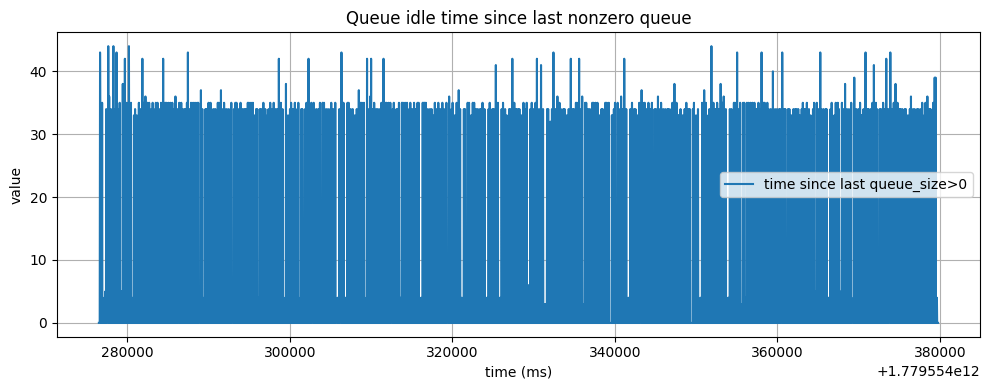

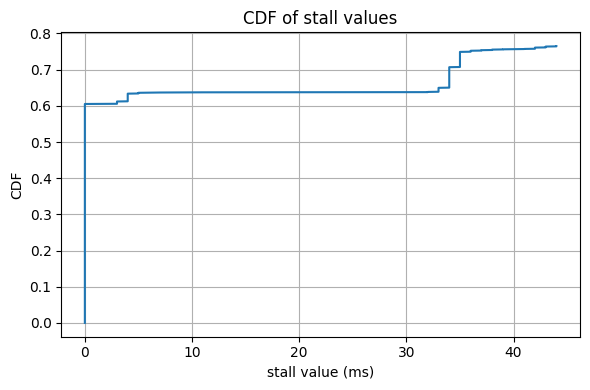

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Load the attached log file
log_path = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/BaseLine/Cudp_Sudp/Exp1/received_queue_size_log_20260523_163720.csv"
df = pd.read_csv(log_path)

# Map CSV columns to expected names
ts_col = "unix_ms"
queue_col = "received_queue_size"
if ts_col not in df.columns:
    raise ValueError(f"Missing timestamp column: {ts_col}")
if queue_col not in df.columns:
    raise ValueError(f"Missing queue size column: {queue_col}")

df = df.sort_values(ts_col).reset_index(drop=True)

# Compute last time when queue_size > 0, then diff
mask = df[queue_col] > 0
last_nonzero_time = df[ts_col].where(mask).ffill()
diff = df[ts_col] - last_nonzero_time

# Plot: 0 if queue_size > 0 else diff
y = np.where(mask, 0, diff)

plt.figure(figsize=(10, 4))
plt.plot(df[ts_col], y, label="time since last queue_size>0")
plt.xlabel("time (ms)")
plt.ylabel("value")
plt.title("Queue idle time since last nonzero queue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# CDF of stall values (including zeros)
stall_values = y
if stall_values.size == 0:
    print("No stall values to plot CDF.")
else:
    x = np.sort(stall_values)
    cdf = np.arange(1, x.size + 1) / x.size
    plt.figure(figsize=(6, 4))
    plt.plot(x, cdf, label="CDF of stall values")
    plt.xlabel("stall value (ms)")
    plt.ylabel("CDF")
    plt.title("CDF of stall values")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Load the packet log (update log_path to your actual file)
log_path = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/Network_Variant2/Ctcp_Stcp/Exp3/unity_packet_log_20260523_194433.csv"
df = pd.read_csv(log_path)

# Map the column names if needed.
col_t1 = next((c for c in df.columns if c.startswith("t1")), "t1_echo")
col_t0 = next((c for c in df.columns if c.startswith("t0")), "t0_echo")
col_t3 = next((c for c in df.columns if c.startswith("t3")), "t3_recv")
col_tq = next((c for c in df.columns if c.startswith("tq")), "tq_dequeue")
col_t4 = next((c for c in df.columns if c.startswith("t4")), "t4_physics")
col_t6 = next((c for c in df.columns if c.startswith("t6")), "t6_unity")
col_t7 = next((c for c in df.columns if "t7" in c), "t7")

# Filter the dataframe to only consider values where t1 is not zero
if col_t1 in df.columns:
    df = df[df[col_t1] != 0].copy()

if not df.empty:
    # The columns we want to forward fill when they have zero values
    ffill_cols = [c for c in [col_t0, col_t1, col_t3, col_tq] if c in df.columns]

    # Replace zeros with NaNs for remaining zero values within those columns if any
    for col in ffill_cols:
        df[col] = df[col].replace(0, np.nan)

    # Forward fill the NaNs (zeros) with the last non-zero value
    df[ffill_cols] = df[ffill_cols].ffill()

    # Calculate RTT_ms
    df["RTT_ms"] = (df[col_t6] - df[col_t1]).clip(lower=0)

    # Calculate Processing_ns
    if col_t4 in df.columns and col_tq in df.columns:
        df["Processing_ns"] = (df[col_t4] - df[col_tq]).clip(lower=0)

    # Calculate QueueDelay_ms
    if col_tq in df.columns and col_t3 in df.columns:
        df["QueueDelay_ms"] = (df[col_tq] - df[col_t3]).clip(lower=0)

    # Calculate Network_ms
    if all(c in df.columns for c in ["RTT_ms", "Processing_ns", "QueueDelay_ms"]):
        # Convert Processing_ns to ms before calculation
        df["Network_ms"] = (df["RTT_ms"] - (df["Processing_ns"] / 1000000.0) - df["QueueDelay_ms"]).clip(lower=0)

    # Calculate RenderDelay_ms
    if col_t7 in df.columns and col_t6 in df.columns:
        df["RenderDelay_ms"] = (df[col_t7] - df[col_t6]).clip(lower=0)

    # Calculate Jitter_ms
    if "RTT_ms" in df.columns:
        df["Jitter_ms"] = df["RTT_ms"].diff().abs().fillna(0)

    print(f"Calculations complete! Total rows (t1 != 0): {len(df)}")
    cols_to_show = [c for c in ["RTT_ms", "Processing_ns", "QueueDelay_ms", "Network_ms", "RenderDelay_ms", "Jitter_ms"] if c in df.columns]
    display(df[cols_to_show])
else:
    print(f"No rows found where {col_t1} is not zero.")

Calculations complete! Total rows (t1 != 0): 2081


,RTT_ms,Processing_ns,QueueDelay_ms,Network_ms,Jitter_ms
225,21,0,20,1.0,0.0
226,23,0,22,1.0,2.0
227,29,0,28,1.0,6.0
228,15,0,15,0.0,14.0
229,16,0,15,1.0,1.0
...,...,...,...,...,...
2806,17,0,16,1.0,3.0
2807,13,0,11,2.0,4.0
2808,28,0,28,0.0,15.0
2809,30,0,30,0.0,2.0


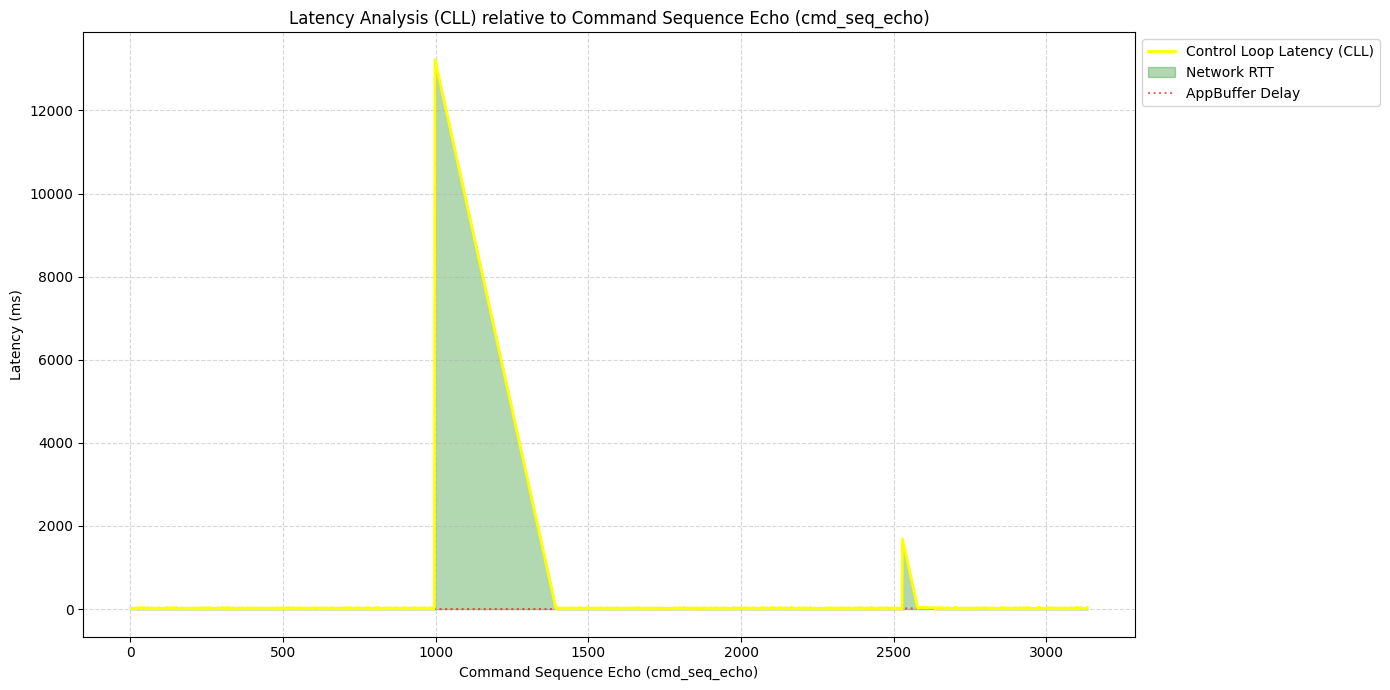

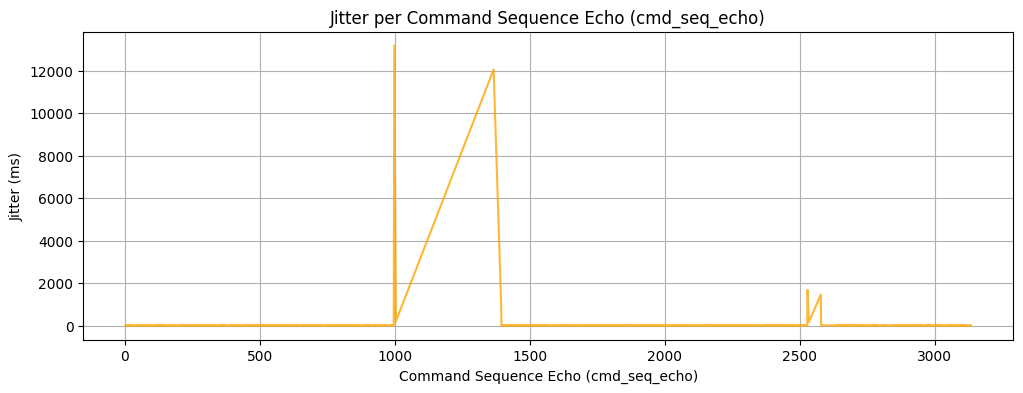

In [ ]:
import matplotlib.pyplot as plt

if "RTT_ms" in df.columns:
    # Ensure Processing_ms exists for consistency
    if "Processing_ns" in df.columns and "Processing_ms" not in df.columns:
        df["Processing_ms"] = df["Processing_ns"] / 1000000.0

    # Use 'cmd_seq' or 'cmd_seq_echo' as the X-axis per user request
    if 'cmd_seq' in df.columns:
        x_axis = df['cmd_seq']
        x_label = "Command Sequence (cmd_seq)"
    elif 'cmd_seq_echo' in df.columns:
        x_axis = df['cmd_seq_echo']
        x_label = "Command Sequence Echo (cmd_seq_echo)"
    else:
        x_axis = df['seq'] if 'seq' in df.columns else range(len(df))
        x_label = "Sequence Number (fallback)"

    plt.figure(figsize=(14, 7))

    # Plot RTT (now CLL) and Components
    plt.plot(x_axis, df["RTT_ms"], label="Control Loop Latency (CLL)", color='yellow', linewidth=2, zorder=5)

    if "Network_ms" in df.columns:
        plt.fill_between(x_axis, 0, df["Network_ms"], label="Network RTT", alpha=0.3, color='green')

    if "QueueDelay_ms" in df.columns:
        plt.plot(x_axis, df["QueueDelay_ms"], label="AppBuffer Delay", color='red', alpha=0.6, linestyle=':')

    plt.xlabel(x_label)
    plt.ylabel("Latency (ms)")
    plt.title(f"Latency Analysis (CLL) relative to {x_label}")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    if "Jitter_ms" in df.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(x_axis, df["Jitter_ms"], label="Jitter", color='orange', alpha=0.8)
        plt.xlabel(x_label)
        plt.ylabel("Jitter (ms)")
        plt.title(f"Jitter per {x_label}")
        plt.grid(True)
        plt.show()
else:
    print("Data not loaded or calculated. Please run the calculation cell first.")

In [ ]:
if 'RTT_ms' in df.columns:
    avg_rtt = df['RTT_ms'].mean()
    print(f"The average RTT (Control Loop Latency) for the current log is: {avg_rtt:.3f} ms")
    print(f"Standard Deviation: {df['RTT_ms'].std():.3f} ms")
    print(f"Max RTT: {df['RTT_ms'].max():.3f} ms")
else:
    print("RTT_ms column not found. Please ensure the calculation cell was run.")

The average RTT (Control Loop Latency) for the current log is: 32.273 ms
Standard Deviation: 409.471 ms
Max RTT: 13217.000 ms


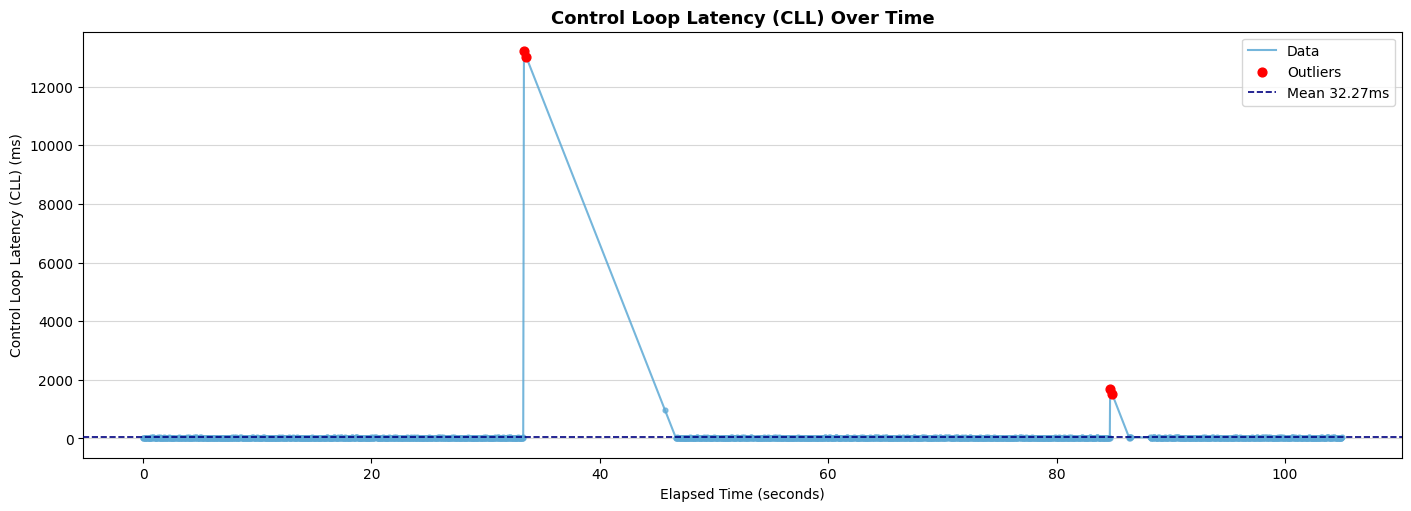

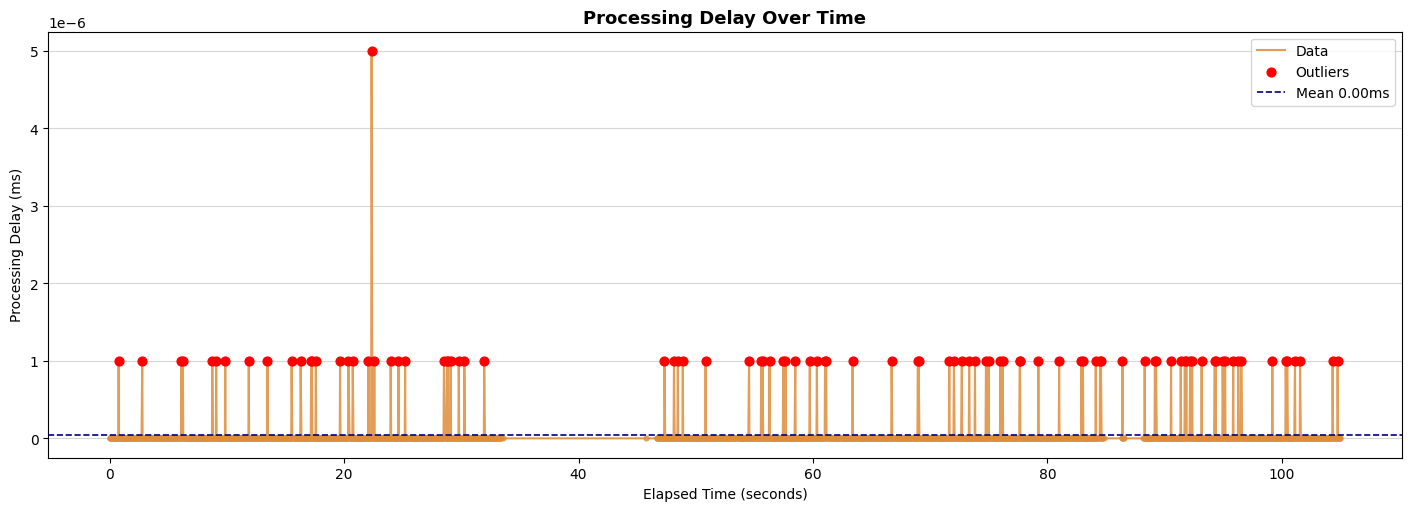

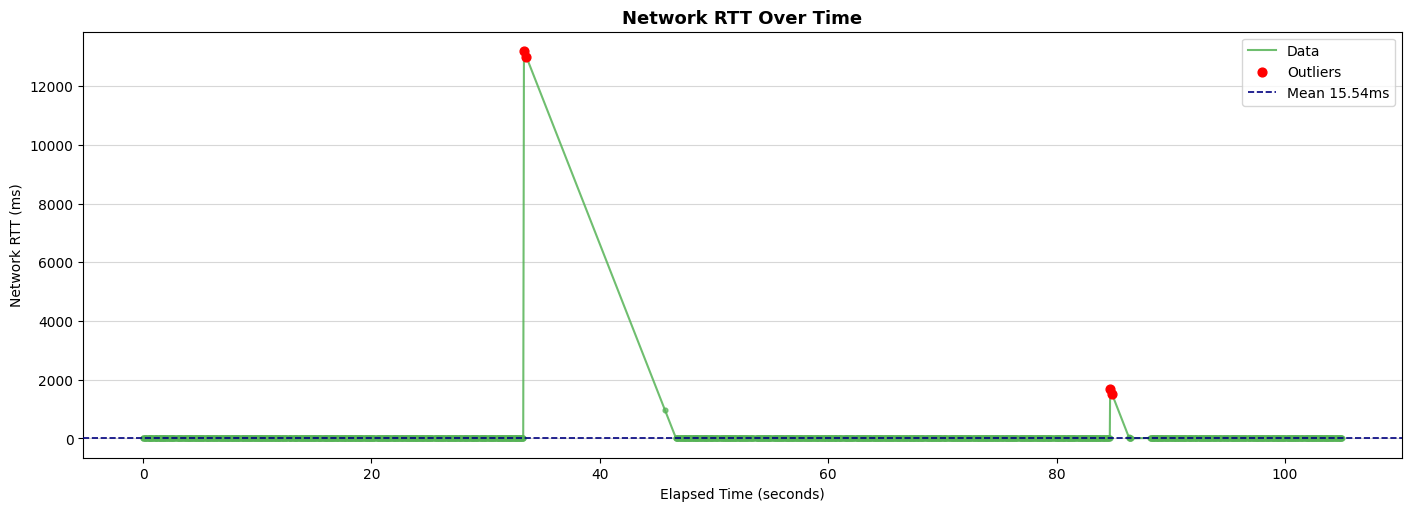

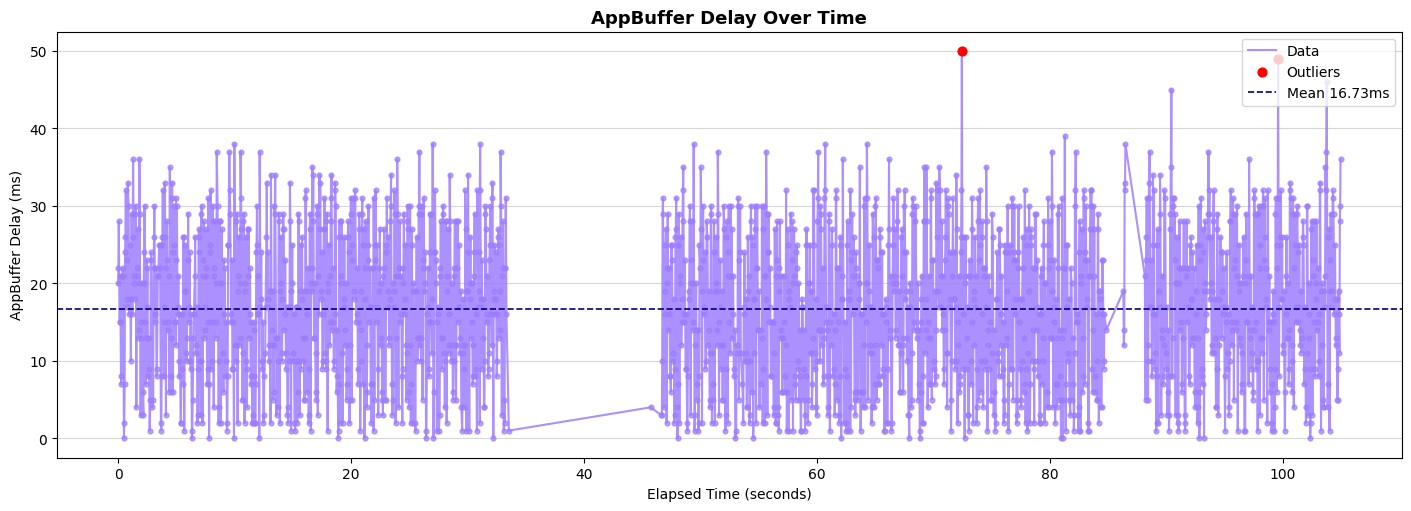

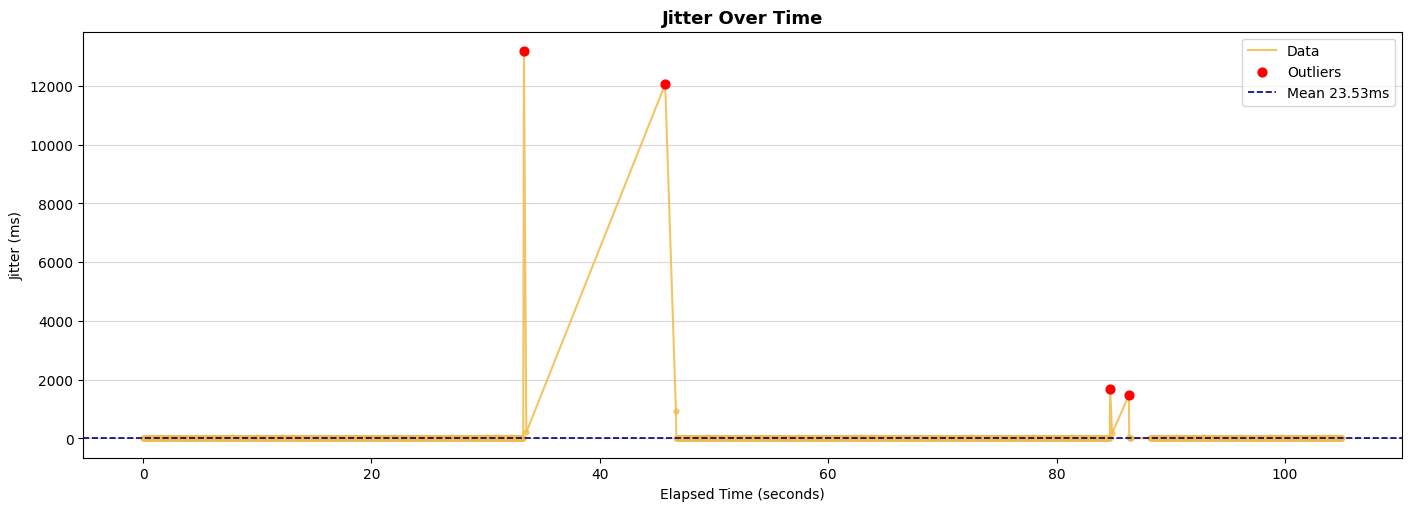

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Ensure Processing_ms exists
if "Processing_ns" in df.columns and "Processing_ms" not in df.columns:
    df["Processing_ms"] = df["Processing_ns"] / 1000000.0

# Ensure MTP_ms exists
col_t1 = next((c for c in df.columns if c.startswith("t1")), "t1_echo")
col_t7 = next((c for c in df.columns if "t7" in c), "t7")
if col_t7 in df.columns and col_t1 in df.columns and "MTP_ms" not in df.columns:
    df["MTP_ms"] = (df[col_t7] - df[col_t1]).clip(lower=0)

if "elapsed_s" not in df.columns:
    if col_t1 in df.columns and not df[col_t1].isna().all():
        df["elapsed_s"] = (df[col_t1] - df[col_t1].iloc[0]) / 1000.0
    else:
        df["elapsed_s"] = range(len(df))

OUTLIER_THRESHOLD = 3

panels = [
    dict(col="RTT_ms",         label="Control Loop Latency (CLL) (ms)", color="#5da9d5", title="Control Loop Latency (CLL) Over Time"),
    dict(col="Processing_ms",  label="Processing Delay (ms)",           color="#e08c39", title="Processing Delay Over Time"),
    dict(col="Network_ms",     label="Network RTT (ms)",                color="#56b356", title="Network RTT Over Time"),
    dict(col="RenderDelay_ms", label="Render Delay (ms)",              color="#d14f4f", title="Render Delay Over Time"),
    dict(col="MTP_ms",         label="MTP (ms)",                       color="#9d7dbf", title="Motion-to-Photon (MTP) Over Time"),
    dict(col="QueueDelay_ms",  label="AppBuffer Delay (ms)",           color="#9d7dff", title="AppBuffer Delay Over Time"),
    dict(col="Jitter_ms",      label="Jitter (ms)",                    color="#f2ba49", title="Jitter Over Time")
]

x = df["elapsed_s"].values

for p in panels:
    if p["col"] not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
    y = df[p["col"]].fillna(0).values
    mean = y.mean()
    std = y.std()
    is_out = y > mean + OUTLIER_THRESHOLD * std
    ax.plot(x, y, color=p["color"], linewidth=1.5, alpha=0.85, zorder=2, label="Data")
    ax.scatter(x[~is_out], y[~is_out], color=p["color"], s=12, zorder=3, alpha=0.7)
    if is_out.any():
        ax.scatter(x[is_out], y[is_out], color="red", s=40, zorder=5, label="Outliers")
    ax.axhline(mean, color="navy", linewidth=1.2, linestyle="--", zorder=4, label=f"Mean {mean:.2f}ms")
    ax.legend(loc="upper right")
    ax.set_title(p["title"], fontsize=13, fontweight="bold")
    ax.set_xlabel("Elapsed Time (seconds)")
    ax.set_ylabel(p["label"])
    ax.grid(axis="y", alpha=0.5)
    plt.show()

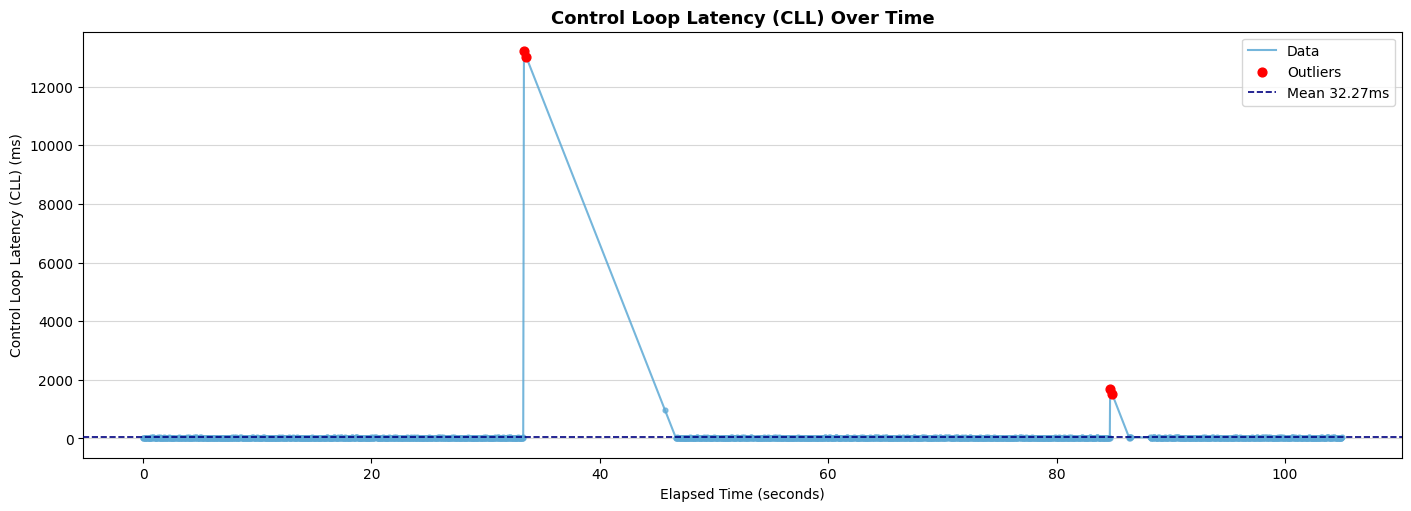

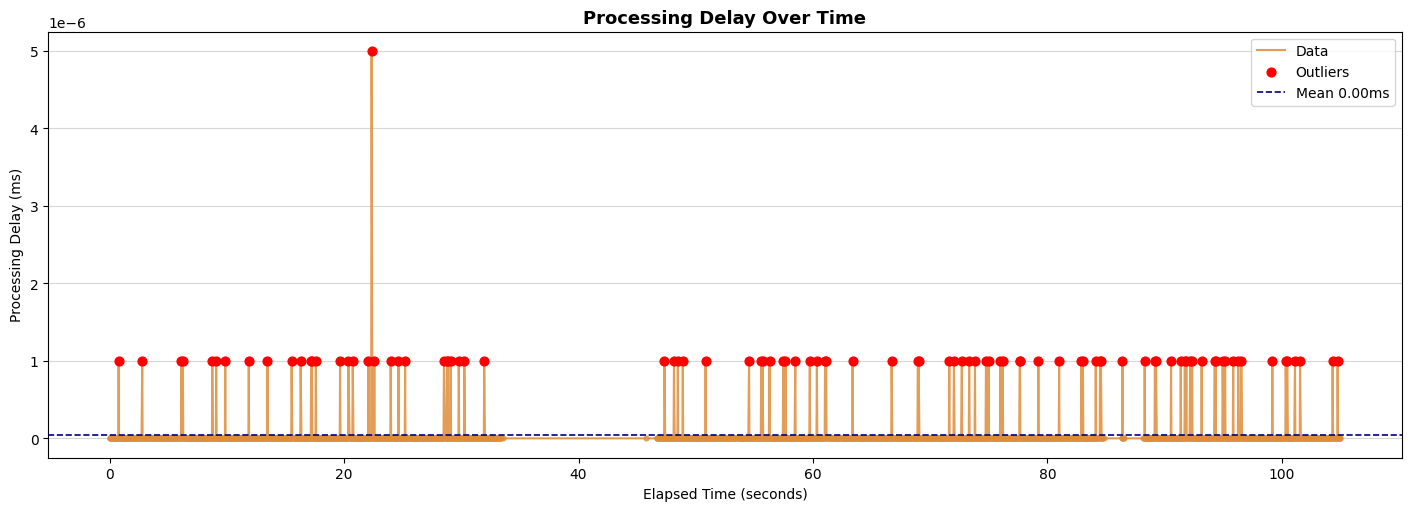

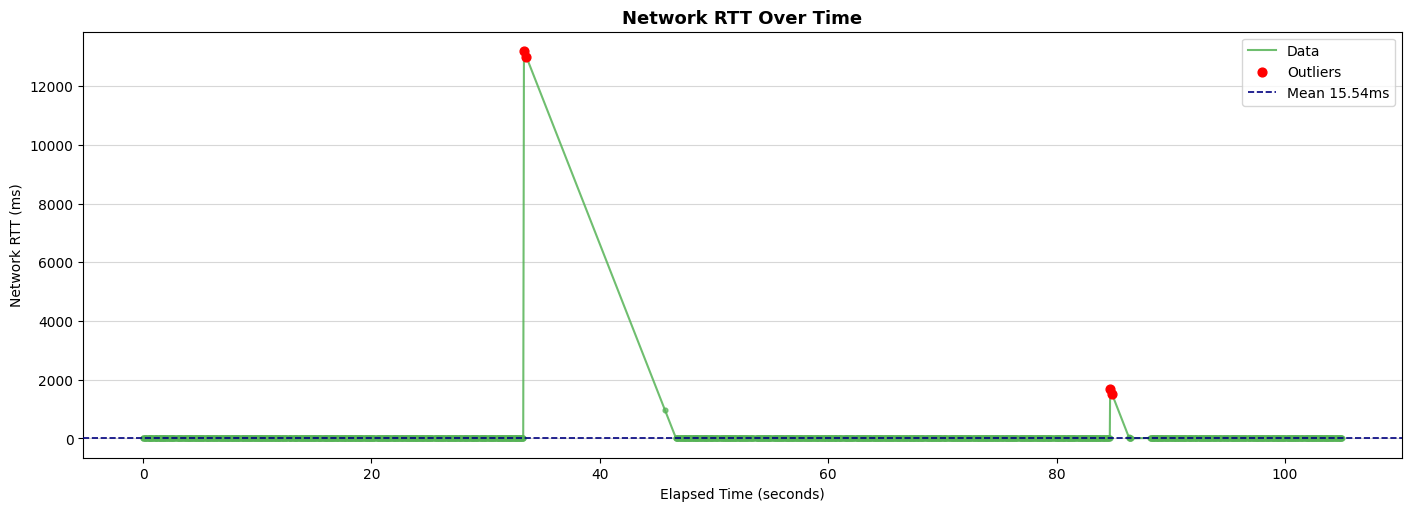

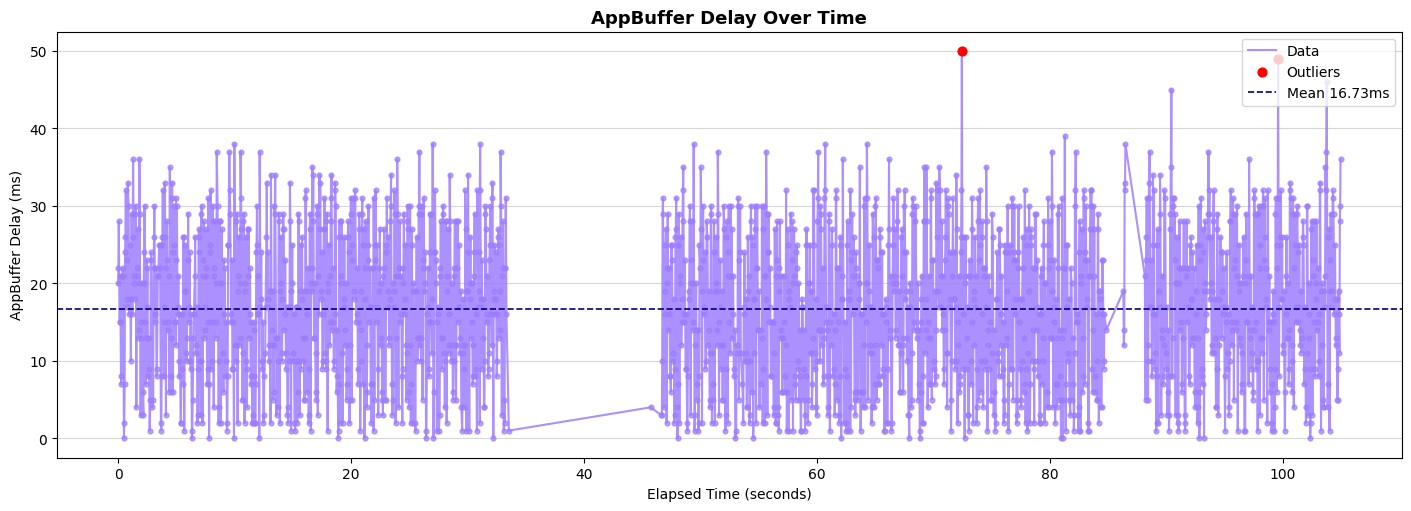

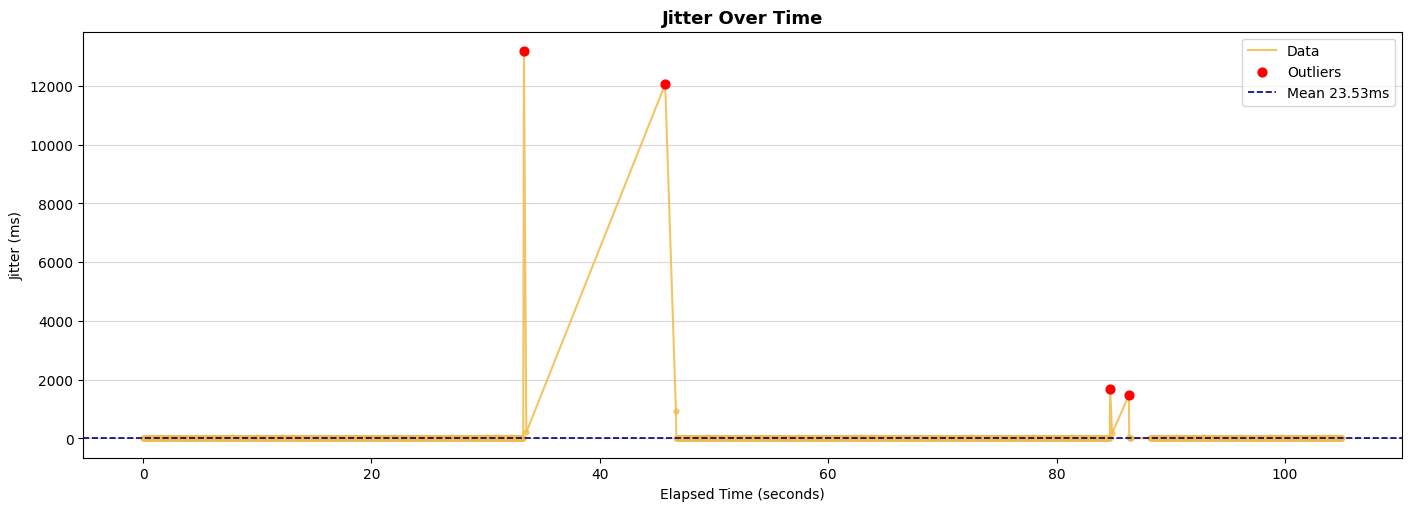

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Ensure Processing_ms exists
if "Processing_ns" in df.columns and "Processing_ms" not in df.columns:
    df["Processing_ms"] = df["Processing_ns"] / 1000000.0

# Ensure MTP_ms exists
col_t1 = next((c for c in df.columns if c.startswith("t1")), "t1_echo")
col_t7 = next((c for c in df.columns if "t7" in c), "t7")
if col_t7 in df.columns and col_t1 in df.columns and "MTP_ms" not in df.columns:
    df["MTP_ms"] = (df[col_t7] - df[col_t1]).clip(lower=0)

if "elapsed_s" not in df.columns:
    if col_t1 in df.columns and not df[col_t1].isna().all():
        df["elapsed_s"] = (df[col_t1] - df[col_t1].iloc[0]) / 1000.0
    else:
        df["elapsed_s"] = range(len(df))

OUTLIER_THRESHOLD = 3

panels = [
    dict(col="RTT_ms",         label="Control Loop Latency (CLL) (ms)", color="#5da9d5", title="Control Loop Latency (CLL) Over Time"),
    dict(col="Processing_ms",  label="Processing Delay (ms)",           color="#e08c39", title="Processing Delay Over Time"),
    dict(col="Network_ms",     label="Network RTT (ms)",                color="#56b356", title="Network RTT Over Time"),
    dict(col="RenderDelay_ms", label="Render Delay (ms)",              color="#d14f4f", title="Render Delay Over Time"),
    dict(col="MTP_ms",         label="MTP (ms)",                       color="#9d7dbf", title="Motion-to-Photon (MTP) Over Time"),
    dict(col="QueueDelay_ms",  label="AppBuffer Delay (ms)",           color="#9d7dff", title="AppBuffer Delay Over Time"),
    dict(col="Jitter_ms",      label="Jitter (ms)",                    color="#f2ba49", title="Jitter Over Time")
]

x = df["elapsed_s"].values

for p in panels:
    if p["col"] not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
    y = df[p["col"]].fillna(0).values
    mean = y.mean()
    std = y.std()
    is_out = y > mean + OUTLIER_THRESHOLD * std
    ax.plot(x, y, color=p["color"], linewidth=1.5, alpha=0.85, zorder=2, label="Data")
    ax.scatter(x[~is_out], y[~is_out], color=p["color"], s=12, zorder=3, alpha=0.7)
    if is_out.any():
        ax.scatter(x[is_out], y[is_out], color="red", s=40, zorder=5, label="Outliers")
    ax.axhline(mean, color="navy", linewidth=1.2, linestyle="--", zorder=4, label=f"Mean {mean:.2f}ms")
    ax.legend(loc="upper right")
    ax.set_title(p["title"], fontsize=13, fontweight="bold")
    ax.set_xlabel("Elapsed Time (seconds)")
    ax.set_ylabel(p["label"])
    ax.grid(axis="y", alpha=0.5)
    plt.show()

In [ ]:
# Replace with the actual generated filename from your Unity PersistentDataPath
csv_file = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/BaseLine/Cudp_Sudp/Exp1/drift_log_20260523_163720.csv"
output_filename = "drift_analysis.png"

✅ Saved Drift Analytics plot to: drift_analysis.png

--- QUANTITATIVE RESULTS ---
Total Commands Expected: -139.512 rads
Total Commands Executed: -139.508 rads
Final Drift Error:       -0.004 rads (0.0% loss)
Maximum Error Recorded:  0.001 rads


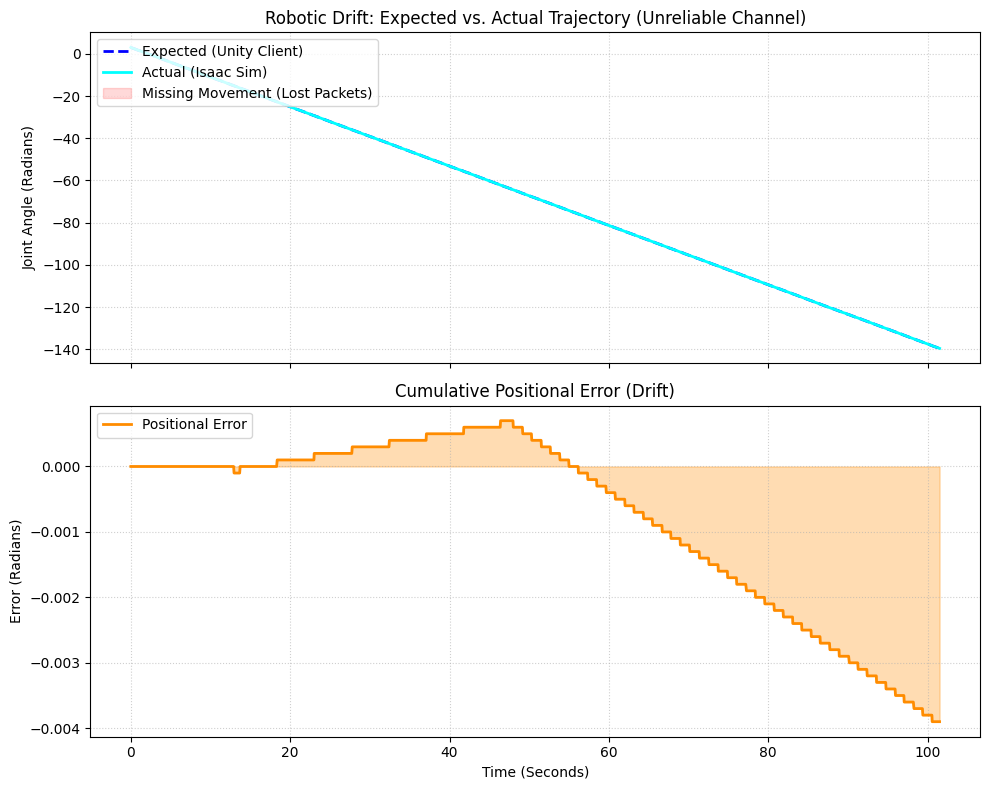

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_drift_analysis(csv_file, output_filename="drift_analysis.png"):
    """
    Plots the expected vs actual trajectory to visualize robotic drift.
    Expected CSV format: Time, ExpectedPos, ActualPos
    """
    if not os.path.exists(csv_file):
        print(f"❌ Could not find {csv_file}")
        print("Please ensure you specify the correct path to the drift log CSV.")
        return

    # Load data
    df = pd.read_csv(csv_file)

    # Ensure columns exist (fallback to index if headers differ slightly)
    time_col = df.columns[0]
    expected_col = df.columns[1]
    actual_col = df.columns[2]

    time_data = df[time_col]
    expected_pos = df[expected_col]
    actual_pos = df[actual_col]

    # Calculate Drift Error (Expected - Actual)
    drift_error = expected_pos - actual_pos

    # Setup the plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # --- Plot 1: Trajectory Divergence ---
    axes[0].plot(time_data, expected_pos, label="Expected (Unity Client)", color='blue', linestyle='--', linewidth=2)
    axes[0].plot(time_data, actual_pos, label="Actual (Isaac Sim)", color='cyan', linewidth=2)

    # Shade the area between the curves to highlight the drift
    axes[0].fill_between(time_data, expected_pos, actual_pos, color='red', alpha=0.15, label="Missing Movement (Lost Packets)")

    axes[0].set_title('Robotic Drift: Expected vs. Actual Trajectory (Unreliable Channel)')
    axes[0].set_ylabel('Joint Angle (Radians)')
    axes[0].legend(loc="upper left")
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # --- Plot 2: Accumulated Error ---
    axes[1].plot(time_data, drift_error, color='darkorange', linewidth=2, label="Positional Error")
    axes[1].fill_between(time_data, 0, drift_error, color='darkorange', alpha=0.3)

    axes[1].set_title('Cumulative Positional Error (Drift)')
    axes[1].set_xlabel('Time (Seconds)')
    axes[1].set_ylabel('Error (Radians)')
    axes[1].legend(loc="upper left")
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # Finalize and Save
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    print(f"✅ Saved Drift Analytics plot to: {output_filename}")

    # Print quantitative results
    final_error = drift_error.iloc[-1]
    max_error = drift_error.max()
    print("\n--- QUANTITATIVE RESULTS ---")
    print(f"Total Commands Expected: {expected_pos.iloc[-1]:.3f} rads")
    print(f"Total Commands Executed: {actual_pos.iloc[-1]:.3f} rads")

    # Protect against divide-by-zero if no movement happened
    expected_total = expected_pos.iloc[-1] if expected_pos.iloc[-1] != 0 else 1
    print(f"Final Drift Error:       {final_error:.3f} rads ({(final_error/expected_total)*100:.1f}% loss)")
    print(f"Maximum Error Recorded:  {max_error:.3f} rads")

    # Display inline in the notebook
    plt.show()

plot_drift_analysis(csv_file, output_filename)

In [ ]:
import pandas as pd
import numpy as np
import os
import glob

# --- Configuration ---
base_paths = [
    "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/BaseLine/Ctcp_Stcp",
    "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/Network_Variant1/Ctcp_Stcp",
    "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/Network_Variant2/Ctcp_Stcp"
]

results = []

def process_folder(folder_path):
    # 1. Handle Packet Log (RTT, Queueing, Network, Processing)
    packet_files = glob.glob(os.path.join(folder_path, "unity_packet_log_*.csv"))
    packet_avg = {}
    if packet_files:
        pdf = pd.read_csv(packet_files[0])
        # Filter rows where t1 is valid (non-zero)
        pdf = pdf[pdf['t1_echo'] != 0].copy()
        if not pdf.empty:
            # RTT = t6_unity - t1_echo
            pdf['RTT'] = (pdf['t6_unity'] - pdf['t1_echo']).clip(lower=0)
            # Processing = t4_physics - tq_dequeue
            pdf['Processing'] = (pdf['t4_physics'] - pdf['tq_dequeue']).clip(lower=0)
            # Queueing = tq_dequeue - t3_recv
            pdf['Queueing'] = (pdf['tq_dequeue'] - pdf['t3_recv']).clip(lower=0)
            # Network = RTT - (Processing/1e6) - Queueing
            pdf['Network'] = (pdf['RTT'] - (pdf['Processing'] / 1000000.0) - pdf['Queueing']).clip(lower=0)

            packet_avg = pdf[['RTT', 'Queueing', 'Network', 'Processing']].mean().to_dict()

    # 2. Handle Latency Log (Rendering, MTP)
    latency_files = glob.glob(os.path.join(folder_path, "latency_log_*.csv"))
    latency_avg = {}
    if latency_files:
        ldf = pd.read_csv(latency_files[0])
        # Use RTT < 1000 to filter out initial spike outliers
        ldf = ldf[ldf['RTT_ms'] < 1000].copy()
        if not ldf.empty:
            latency_avg = ldf[['RenderDelay_ms', 'MTP_ms']].mean().to_dict()
            # Rename keys for reporting
            latency_avg = {"Rendering": latency_avg.get('RenderDelay_ms'), "MTP": latency_avg.get('MTP_ms')}

    if packet_avg or latency_avg:
        combined = {**packet_avg, **latency_avg}
        combined['Folder'] = os.path.relpath(folder_path, "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/")
        return combined
    return None

# --- Execution ---
for base in base_paths:
    if not os.path.exists(base):
        print(f"Path not found: {base}")
        continue

    # Get all subdirectories (Exp1, Exp2, etc.)
    subfolders = [os.path.join(base, d) for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
    for folder in sorted(subfolders):
        data = process_folder(folder)
        if data:
            results.append(data)

# --- Report ---
if results:
    report_df = pd.DataFrame(results)
    # Reorder columns for clarity
    cols = ['Folder', 'RTT', 'Queueing', 'Network', 'Processing', 'Rendering', 'MTP']
    display(report_df[[c for c in cols if c in report_df.columns]].round(3))
else:
    print("No logs found in the specified paths.")

,Folder,RTT,Queueing,Network,Processing,Rendering,MTP
0,BaseLine/Ctcp_Stcp/Exp1,18.050,17.132,0.919,0.058,17.994,36.448
1,BaseLine/Ctcp_Stcp/Exp2,17.472,16.580,0.893,0.042,17.095,34.654
2,BaseLine/Ctcp_Stcp/Exp3,17.982,16.976,1.006,0.046,16.629,34.693
3,Network_Variant1/Ctcp_Stcp/Exp1,17.821,16.849,0.974,0.044,17.969,36.149
4,Network_Variant1/Ctcp_Stcp/Exp2,17.675,16.697,0.978,0.036,16.866,34.620
5,Network_Variant1/Ctcp_Stcp/Exp3,17.758,16.828,0.929,0.047,16.647,34.517
6,Network_Variant2/Ctcp_Stcp/Exp1,17.721,16.755,0.968,0.053,17.144,34.915
7,Network_Variant2/Ctcp_Stcp/Exp2,20.544,16.723,3.822,0.056,17.213,35.006
8,Network_Variant2/Ctcp_Stcp/Exp3,32.273,16.733,15.540,0.047,16.539,34.337


Network Variant 2 Results:


,RTT,Queueing,Network,Processing,Rendering,MTP,Folder
6,17.721235,16.754911,0.967727,0.052853,17.144113,34.914998,Network_Variant2/Ctcp_Stcp/Exp1
7,20.544390,16.722927,3.821951,0.056098,17.213265,35.006122,Network_Variant2/Ctcp_Stcp/Exp2
8,32.272946,16.732821,15.540125,0.046612,16.539241,34.336709,Network_Variant2/Ctcp_Stcp/Exp3


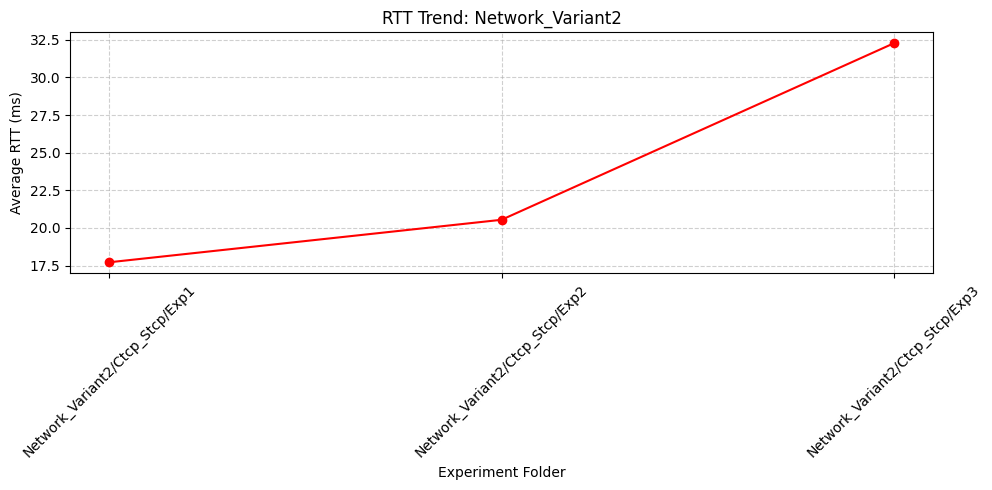

In [ ]:
import matplotlib.pyplot as plt

# Filter and display the Network_Variant2 results to verify
nv2_results = report_df[report_df['Folder'].str.contains('Network_Variant2')].copy()
print("Network Variant 2 Results:")
display(nv2_results)

# Plotting RTT trend for Network_Variant2
plt.figure(figsize=(10, 5))
plt.plot(nv2_results['Folder'], nv2_results['RTT'], marker='o', linestyle='-', color='red')
plt.title('RTT Trend: Network_Variant2')
plt.xlabel('Experiment Folder')
plt.ylabel('Average RTT (ms)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

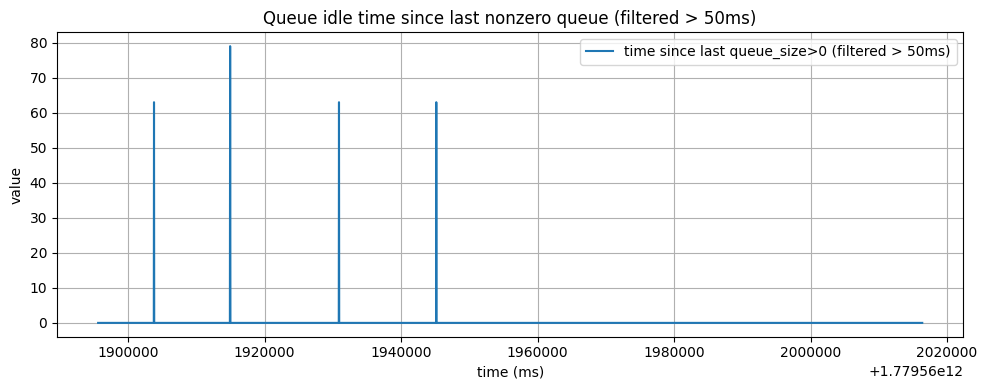

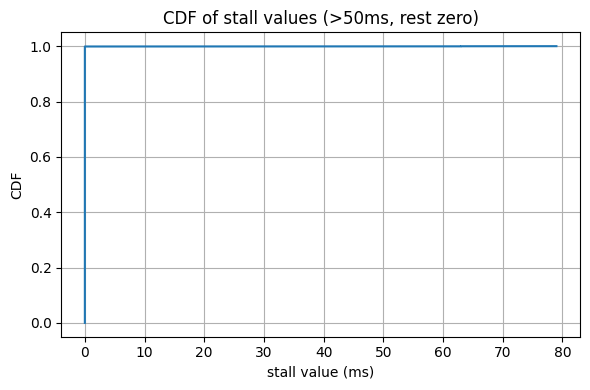

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Load the attached log file
log_path = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final/Network_Variant1/Ctcp_Stcp/Exp1/received_queue_size_log_20260523_184455.csv"
df = pd.read_csv(log_path)

# Map CSV columns to expected names
ts_col = "unix_ms"
queue_col = "received_queue_size"
if ts_col not in df.columns:
    raise ValueError(f"Missing timestamp column: {ts_col}")
if queue_col not in df.columns:
    raise ValueError(f"Missing queue size column: {queue_col}")

df = df.sort_values(ts_col).reset_index(drop=True)

# Compute last time when queue_size > 0, then diff
mask = df[queue_col] > 0
if not mask.any():
    print("No nonzero queue size found; nothing to plot.")
else:
    last_idx = df.index[mask][-1]
    df_valid = df.loc[:last_idx].copy()
    mask_valid = df_valid[queue_col] > 0
    last_nonzero_time = df_valid[ts_col].where(mask_valid).ffill()
    diff = df_valid[ts_col] - last_nonzero_time

    # Original calculation for y (time since last queue_size > 0)
    y_raw = np.where(mask_valid, 0, diff)

    # Apply user's condition: for stall value greater than 100ms, rest keep as zero
    y = np.where(y_raw > 50, y_raw, 0)

    plt.figure(figsize=(10, 4))
    plt.plot(df_valid[ts_col], y, label="time since last queue_size>0 (filtered > 50ms)")
    plt.xlabel("time (ms)")
    plt.ylabel("value")
    plt.title("Queue idle time since last nonzero queue (filtered > 50ms)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # CDF of stall values (including zeros)
    stall_values = y

    # Filter out NaN values before sorting for CDF
    stall_values_for_cdf = stall_values[~np.isnan(stall_values)]

    if stall_values_for_cdf.size == 0:
        print("No valid stall values to plot CDF after filtering.")
    else:
        x = np.sort(stall_values_for_cdf)
        cdf = np.arange(1, x.size + 1) / x.size
        plt.figure(figsize=(6, 4))
        plt.plot(x, cdf, label="CDF of stall values (filtered > 50ms)")
        plt.xlabel("stall value (ms)")
        plt.ylabel("CDF")
        plt.title("CDF of stall values (>50ms, rest zero)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
import glob

root_path = "/content/drive/MyDrive/Capstone /Capstone/Client_Experimentation_final"
variants = ["BaseLine", "Network_Variant1", "Network_Variant2"]
protocols = ["Cudp_Sudp", "Ctcp_Stcp"]

def calculate_missing_packets(csv_path):
    try:
        df = pd.read_csv(csv_path)
        if 'seq' not in df.columns:
            return None
        seq = pd.to_numeric(df['seq'], errors='coerce').dropna().astype(int)
        if seq.empty:
            return 0.0
        expected_range = seq.max() - seq.min() + 1
        observed_count = seq.nunique()
        missing_count = expected_range - observed_count
        return max(0, missing_count)
    except:
        return None

results = []
for proto in protocols:
    print(f"\n{'UDP' if 'udp' in proto.lower() else 'TCP'}")
    for var in variants:
        folder_path = os.path.join(root_path, var, proto)
        exp_missing = []
        if os.path.exists(folder_path):
            subfolders = [os.path.join(folder_path, d) for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
            for exp in subfolders:
                files = glob.glob(os.path.join(exp, "unity_packet_log_*.csv"))
                for f in files:
                    m = calculate_missing_packets(f)
                    if m is not None: exp_missing.append(m)

        avg_loss = np.mean(exp_missing) if exp_missing else 0.0
        display_name = var.replace('_', ' ').replace('Variant', 'variant')
        print(f"{display_name}: {avg_loss:.2f} missing packets (avg)")


UDP
BaseLine: 0.00 missing packets (avg)
Network variant1: 0.00 missing packets (avg)
Network variant2: 273.67 missing packets (avg)

TCP
BaseLine: 0.00 missing packets (avg)
Network variant1: 0.00 missing packets (avg)
Network variant2: 0.00 missing packets (avg)


In [ ]:
import pandas as pd
import numpy as np
import os
import glob

# --- Paths Configuration ---
base_folders = [
    "/content/drive/MyDrive/Capstone /Capstone/Server_Experimentation_final/BaseLine",
    "/content/drive/MyDrive/Capstone /Capstone/Server_Experimentation_final/Network_Variant1",
    "/content/drive/MyDrive/Capstone /Capstone/Server_Experimentation_final/Network_Variant2"
]
protocols = ["Cudp_Sudp", "Ctcp_Stcp"]

def calculate_missing_cmd_seq(csv_path):
    try:
        df = pd.read_csv(csv_path)
        # Target column remains 'cmd_seq'
        if 'cmd_seq' not in df.columns:
            return None

        # Convert to numeric and remove NaNs or zeros
        seqs = pd.to_numeric(df['cmd_seq'], errors='coerce').dropna().astype(int)
        seqs = seqs[seqs > 0]

        if seqs.empty:
            return 0

        # Calculate gaps in sequence
        expected_range = seqs.max() - seqs.min() + 1
        actual_unique = seqs.nunique()
        return max(0, expected_range - actual_unique)
    except Exception:
        return None

# --- Execution and Reporting ---
for proto in protocols:
    header = "UDP" if "udp" in proto.lower() else "TCP"
    print(f"\n{header}")

    for base in base_folders:
        target_path = os.path.join(base, proto)
        all_losses = []

        if os.path.exists(target_path):
            # Look for sub-experiment folders (Exp1, Exp2, etc.)
            sub_dirs = [os.path.join(target_path, d) for d in os.listdir(target_path) if os.path.isdir(os.path.join(target_path, d))]
            if not sub_dirs: sub_dirs = [target_path]

            for folder in sub_dirs:
                # UPDATED: Looking for isaac_packet_log files instead of unity_packet_log
                files = glob.glob(os.path.join(folder, "isaac_packet_log_*.csv"))
                for f in files:
                    loss = calculate_missing_cmd_seq(f)
                    if loss is not None:
                        all_losses.append(loss)

        avg_loss = np.mean(all_losses) if all_losses else 0.0
        variant_label = os.path.basename(base).replace('_', ' ').replace('Variant', 'variant')
        print(f"{variant_label}: {avg_loss:.2f} missing cmd_seq (avg)")


UDP
BaseLine: 0.00 missing cmd_seq (avg)
Network variant1: 0.00 missing cmd_seq (avg)
Network variant2: 305.00 missing cmd_seq (avg)

TCP
BaseLine: 0.00 missing cmd_seq (avg)
Network variant1: 0.00 missing cmd_seq (avg)
Network variant2: 0.00 missing cmd_seq (avg)
